### Import Data and Required Packages

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns
import math
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder, MinMaxScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, mean_squared_error, r2_score
import itertools

#### Import the CSV Data as Pandas DataFrame

In [11]:
df = pd.read_csv('/content/ames_housing.csv')
display(df.head())

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


#### Show Top 5 Records

In [12]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


#### Shape of the dataset

In [13]:
df.shape

(2930, 82)

### Dataset information

*  Dataset name: Ames Housing
*   Domain: Real estate / housing prices
*   Rows (observations): 2,930 houses
*   Columns (features): 82 variables
*   Target variable: SalePrice

### Data Checks to perform
- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

###  Check Missing values

In [14]:
df.isna()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,False,False,False,False,False,False,False,True,False,False,...,False,True,True,True,False,False,False,False,False,False
1,False,False,False,False,False,False,False,True,False,False,...,False,True,False,True,False,False,False,False,False,False
2,False,False,False,False,False,False,False,True,False,False,...,False,True,True,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,True,False,False,...,False,True,True,True,False,False,False,False,False,False
4,False,False,False,False,False,False,False,True,False,False,...,False,True,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,False,False,False,False,False,False,False,True,False,False,...,False,True,False,True,False,False,False,False,False,False
2926,False,False,False,False,True,False,False,True,False,False,...,False,True,False,True,False,False,False,False,False,False
2927,False,False,False,False,False,False,False,True,False,False,...,False,True,False,False,False,False,False,False,False,False
2928,False,False,False,False,False,False,False,True,False,False,...,False,True,True,True,False,False,False,False,False,False


## Lot of missing values in this dataset.

In [16]:
df.isnull().sum()

,0
Order,0
PID,0
MS SubClass,0
MS Zoning,0
Lot Frontage,490
...,...
Mo Sold,0
Yr Sold,0
Sale Type,0
Sale Condition,0


In [17]:
# Separate by type
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(exclude='object').columns

# Impute numeric with median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Impute categorical with mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

## Applied filna above dataset.

In [18]:
df.isnull().sum()

,0
Order,0
PID,0
MS SubClass,0
MS Zoning,0
Lot Frontage,0
...,...
Mo Sold,0
Yr Sold,0
Sale Type,0
Sale Condition,0


#### There are no missing values in the data set

In [19]:
df.isna()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2926,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2927,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2928,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Provide 'False', That means no missing in the dataset.

### Check Duplicates

In [20]:
df.duplicated().sum()

np.int64(0)

#### There are no duplicates  values in the data set

###  Check data types

In [21]:
# Check Null and Dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2930 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            2930 non-null   object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

### Checking the number of unique values of each column

In [22]:
df.nunique()

,0
Order,2930
PID,2930
MS SubClass,16
MS Zoning,7
Lot Frontage,128
...,...
Mo Sold,12
Yr Sold,5
Sale Type,10
Sale Condition,6


### Check statistics of data set

In [23]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.019795,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.096928,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,21.326422,7880.017759,1.411026,1.111537,30.245361,20.860286,178.634545,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,60.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,78.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,162.750000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


- From the numerical feature descriptions, several area-related variables such as 1st Flr SF, Gr Liv Area, and Total Bsmt SF show large variation, indicating that house sizes differ significantly across properties.
- The quality-related variables like Overall Qual and Overall Cond are measured on a scale from 1 to 10, where most houses tend to fall in the average-to-good quality range.
- Construction year variables (Year Built and Year Remod/Add) indicate that the dataset contains both older and recently remodeled houses.
- Some variables have minimum values of 0, such as Pool Area, Garage Area, and Fireplaces, meaning many houses do not include these features.
- The target variable SalePrice has a very wide range, showing substantial differences in house prices across the dataset.
- Features related to living space and quality, including Gr Liv Area, Overall Qual, and Garage Cars, generally have strong positive relationships with SalePrice.

### Exploring Data

In [24]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,Grvl,IR1,Lvl,...,0,Ex,MnPrv,Shed,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,Grvl,Reg,Lvl,...,0,Ex,MnPrv,Shed,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,Grvl,IR1,Lvl,...,0,Ex,MnPrv,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,Grvl,Reg,Lvl,...,0,Ex,MnPrv,Shed,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,Grvl,IR1,Lvl,...,0,Ex,MnPrv,Shed,0,3,2010,WD,Normal,189900


In [25]:
## Encode categorical variables (many! Use OneHotEncoder)
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# Select only categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
X_cat = df[cat_cols]

In [26]:
from sklearn.compose import ColumnTransformer

# Initialize the encoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Column transformer: apply OneHotEncoder to categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', ohe, cat_cols)
    ],
    remainder='drop'  # drop other columns (keep only encoded for now)
)

# Fit and transform
X_encoded = preprocessor.fit_transform(X_cat)

# Convert to DataFrame
encoded_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
X_encoded_df = pd.DataFrame(X_encoded, columns=encoded_feature_names)

# Show result
print(X_encoded_df.head())


   MS Zoning_A (agr)  MS Zoning_C (all)  MS Zoning_FV  MS Zoning_I (all)  \
0                0.0                0.0           0.0                0.0   
1                0.0                0.0           0.0                0.0   
2                0.0                0.0           0.0                0.0   
3                0.0                0.0           0.0                0.0   
4                0.0                0.0           0.0                0.0   

   MS Zoning_RH  MS Zoning_RL  MS Zoning_RM  Street_Grvl  Street_Pave  \
0           0.0           1.0           0.0          0.0          1.0   
1           1.0           0.0           0.0          0.0          1.0   
2           0.0           1.0           0.0          0.0          1.0   
3           0.0           1.0           0.0          0.0          1.0   
4           0.0           1.0           0.0          0.0          1.0   

   Alley_Grvl  ...  Sale Type_New  Sale Type_Oth  Sale Type_VWD  \
0         1.0  ...            0.0    

- OneHotEncoder converts categorical values into numerical binary columns.
handle_unknown='ignore' prevents errors when unseen categories appear during prediction.
- ColumnTransformer applies encoding only to selected categorical columns (cat_cols).
fit_transform() learns categories and transforms the dataset.
- Encoded feature names are extracted using get_feature_names_out().
- The transformed output is converted into a pandas DataFrame for easier analysis.
- Finally, the first five rows of the encoded dataset are displayed using head().

In [27]:
# Select numeric columns
num_cols = df.select_dtypes(exclude=['object']).columns

# Combine encoder with passthrough for numeric features
preprocessor_full = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ],
    remainder='passthrough'  # keep numeric columns
)

X_full = preprocessor_full.fit_transform(df)

# Get column names
encoded_cat_names = preprocessor_full.named_transformers_['cat'].get_feature_names_out(cat_cols)
all_column_names = list(encoded_cat_names) + list(num_cols)

# Convert to DataFrame
X_final = pd.DataFrame(X_full, columns=all_column_names)
print(X_final.head())


   MS Zoning_A (agr)  MS Zoning_C (all)  MS Zoning_FV  MS Zoning_I (all)  \
0                0.0                0.0           0.0                0.0   
1                0.0                0.0           0.0                0.0   
2                0.0                0.0           0.0                0.0   
3                0.0                0.0           0.0                0.0   
4                0.0                0.0           0.0                0.0   

   MS Zoning_RH  MS Zoning_RL  MS Zoning_RM  Street_Grvl  Street_Pave  \
0           0.0           1.0           0.0          0.0          1.0   
1           1.0           0.0           0.0          0.0          1.0   
2           0.0           1.0           0.0          0.0          1.0   
3           0.0           1.0           0.0          0.0          1.0   
4           0.0           1.0           0.0          0.0          1.0   

   Alley_Grvl  ...  Wood Deck SF  Open Porch SF  Enclosed Porch  3Ssn Porch  \
0         1.0  ...       

- Numeric columns are identified using select_dtypes().
- OneHotEncoder converts categorical columns (cat_cols) into binary encoded features.
handle_unknown='ignore' avoids errors from unseen categories.
remainder='passthrough' keeps all numeric columns unchanged.
fit_transform() applies preprocessing to the entire dataset.
- Encoded categorical column names are extracted using get_feature_names_out().
- Encoded categorical names and numeric column names are combined.
- The transformed data is converted into a pandas DataFrame with proper column names.
- Finally, the first five rows of the processed dataset are displayed.

## Box Plot to identify outliers

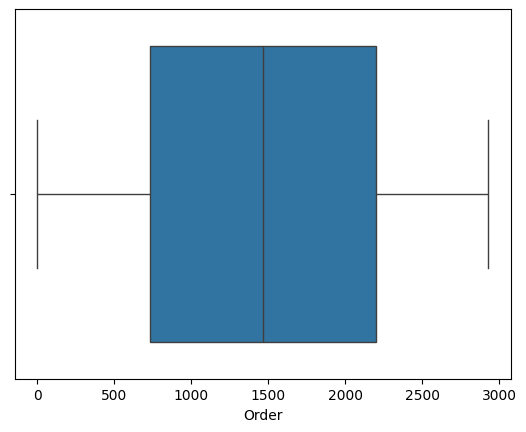

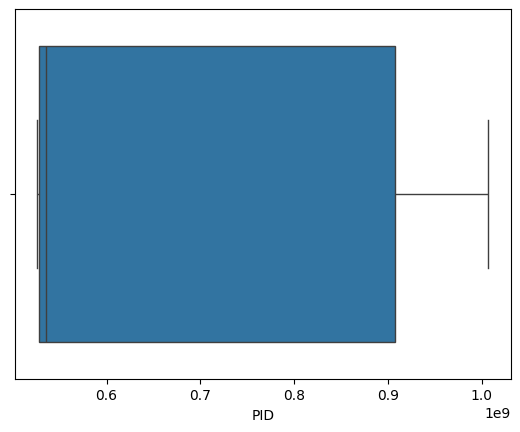

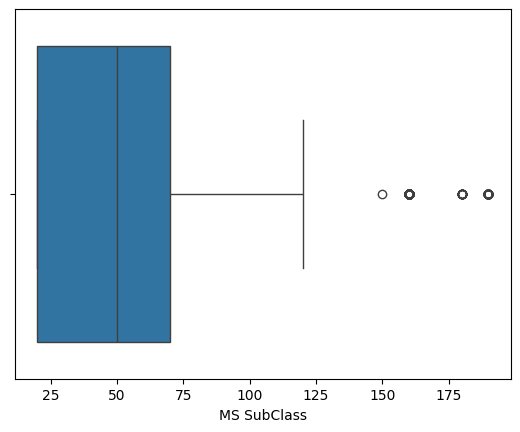

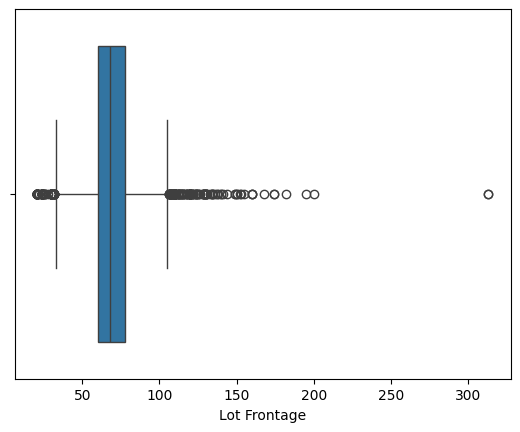

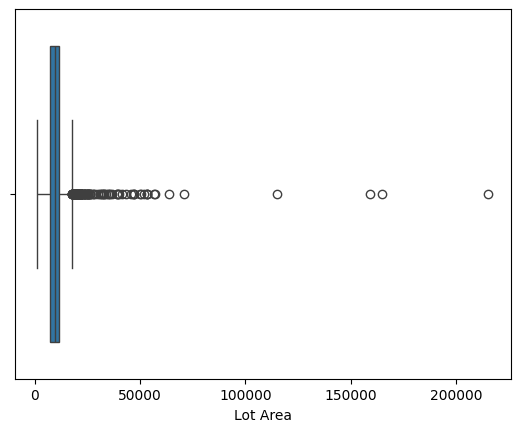

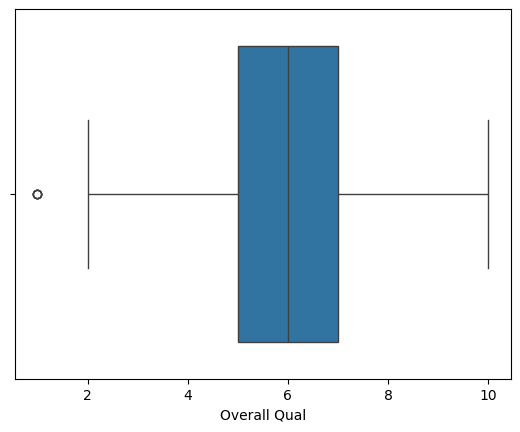

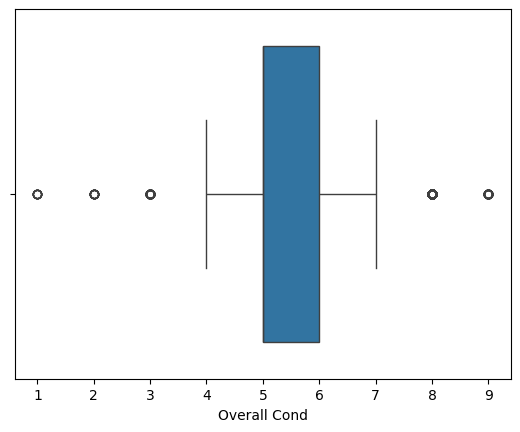

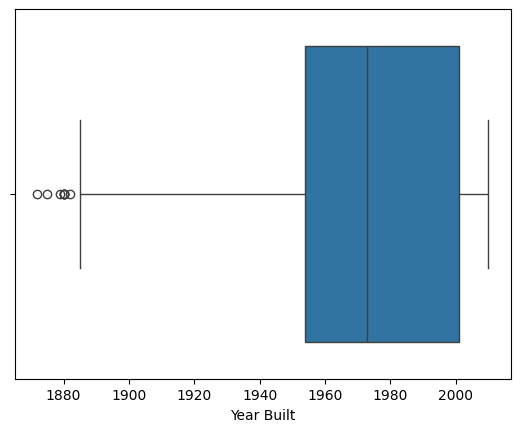

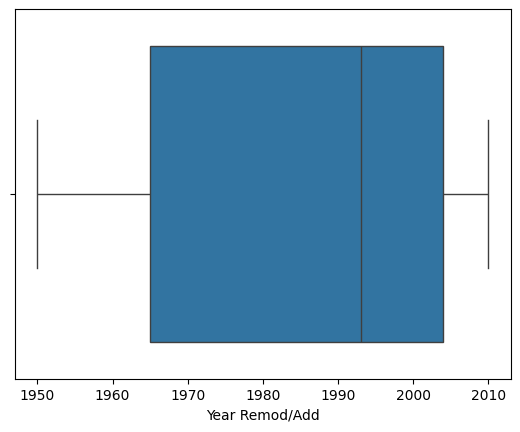

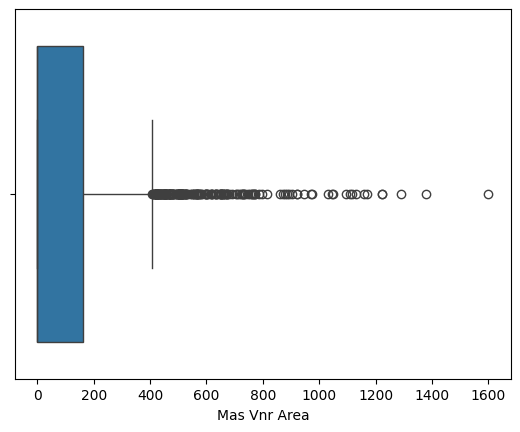

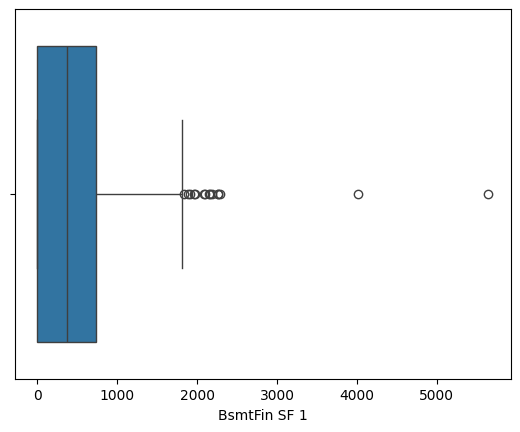

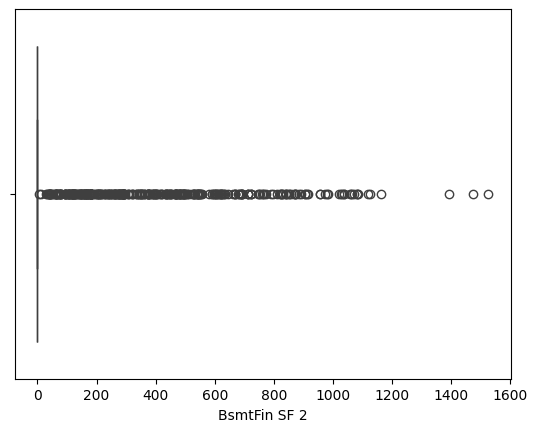

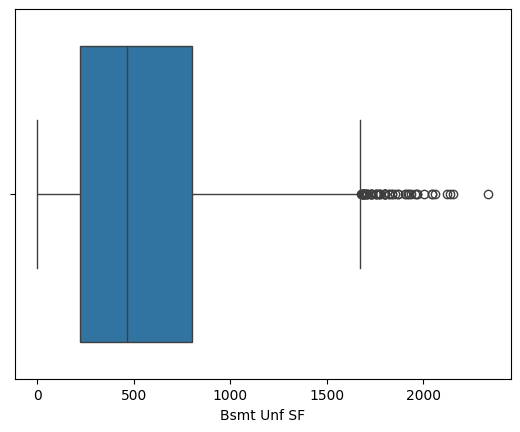

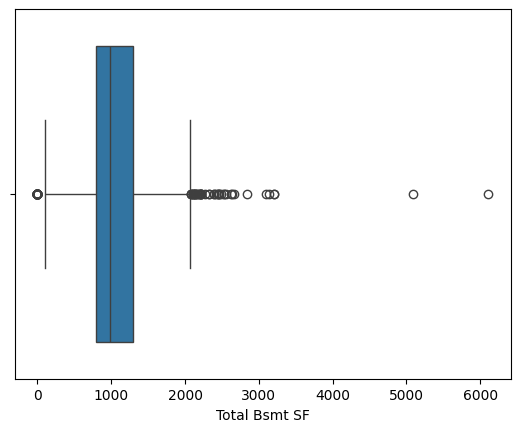

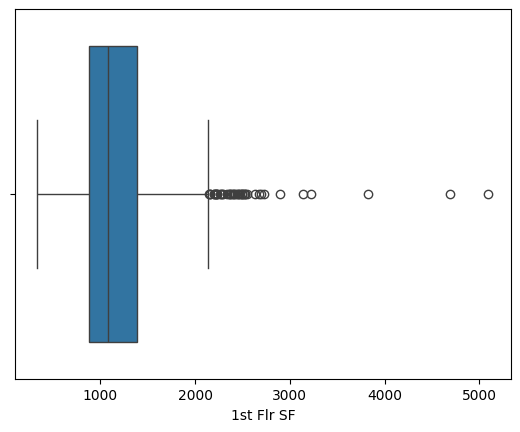

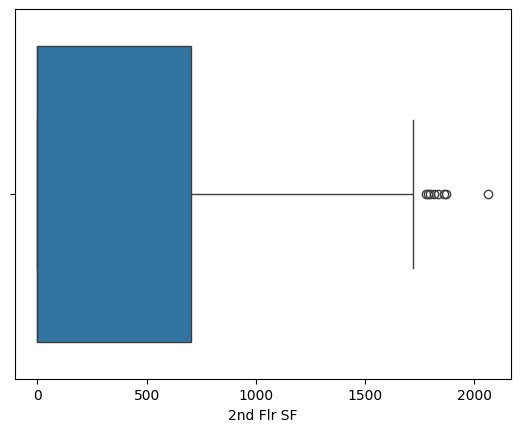

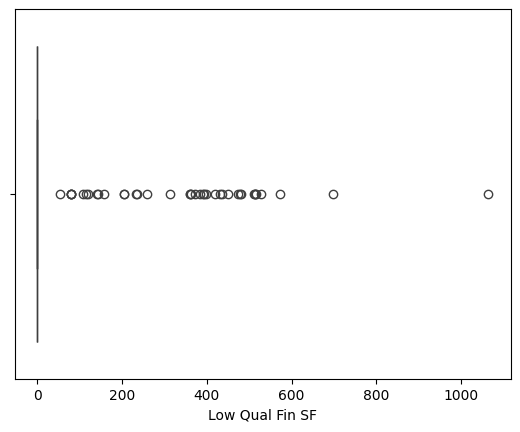

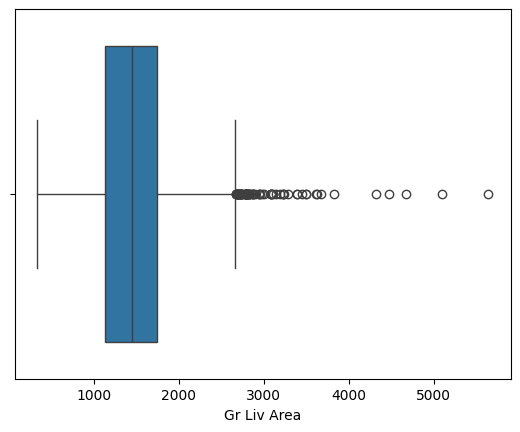

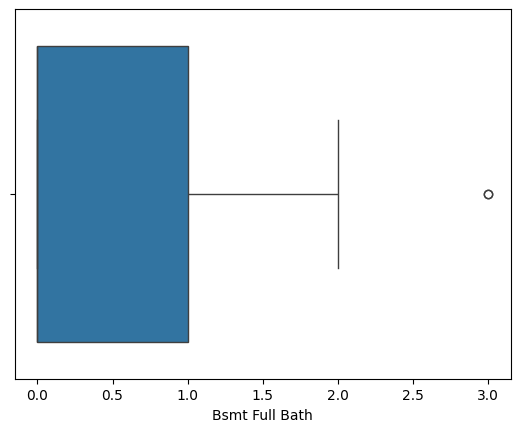

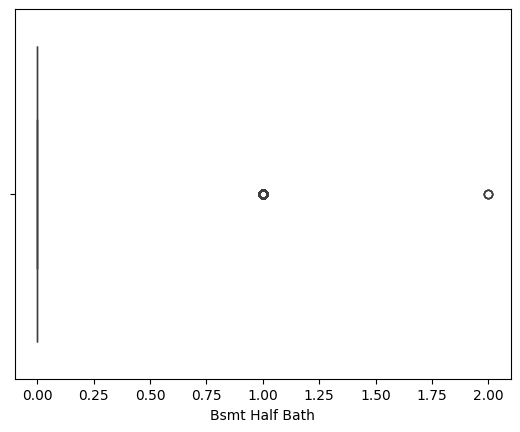

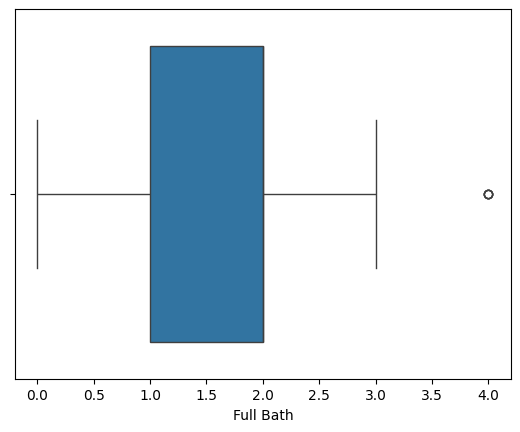

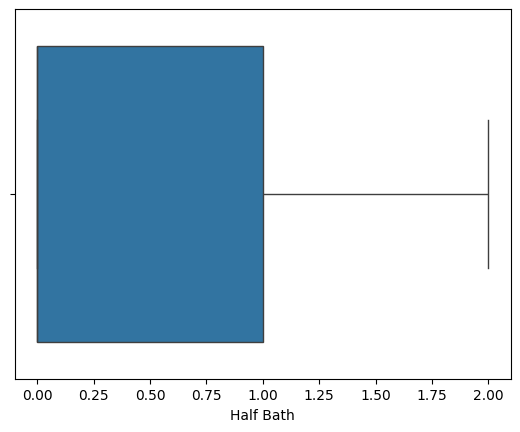

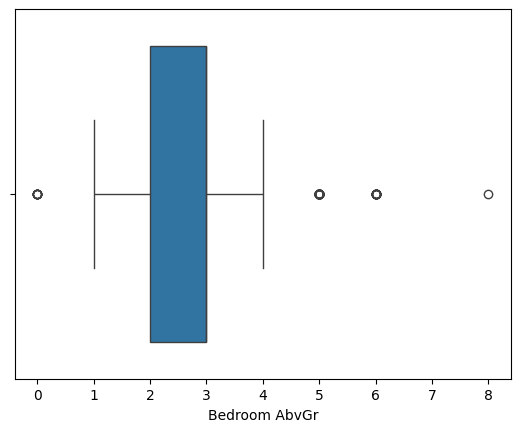

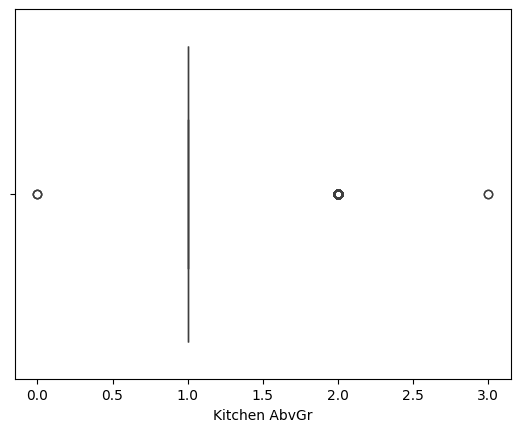

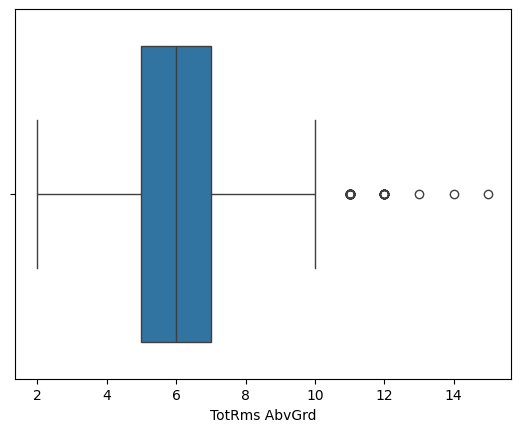

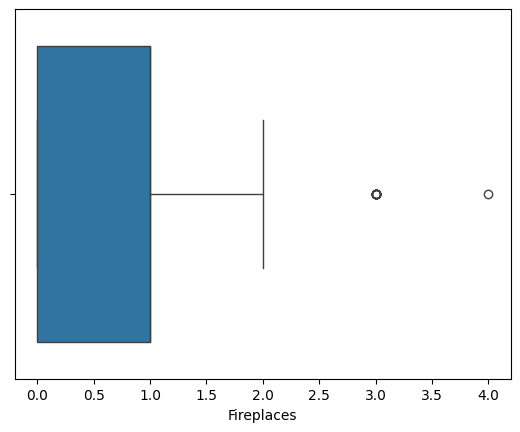

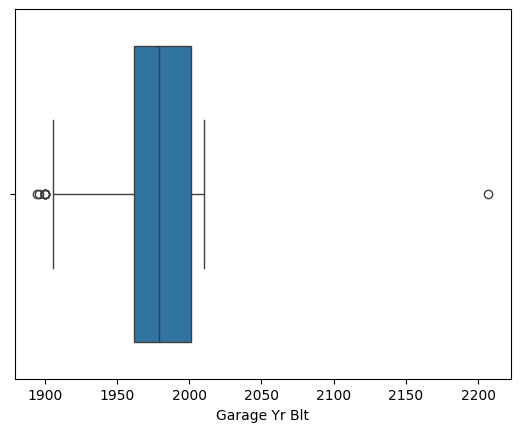

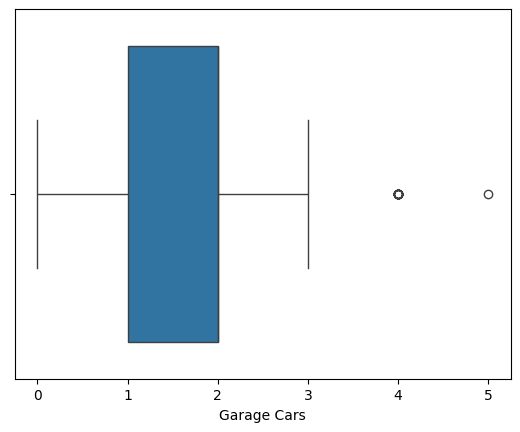

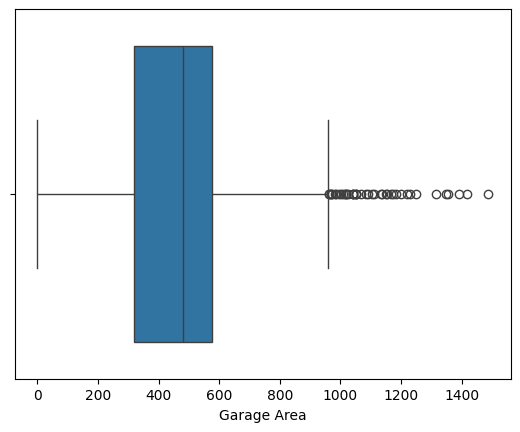

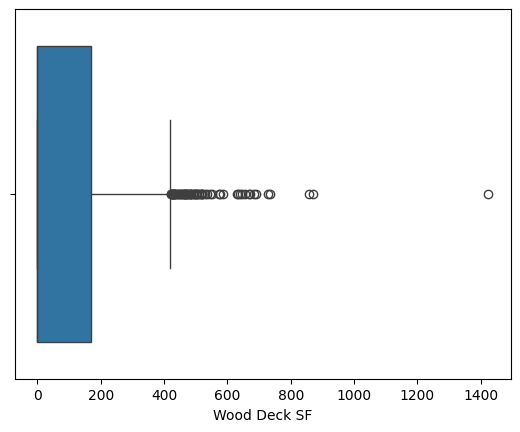

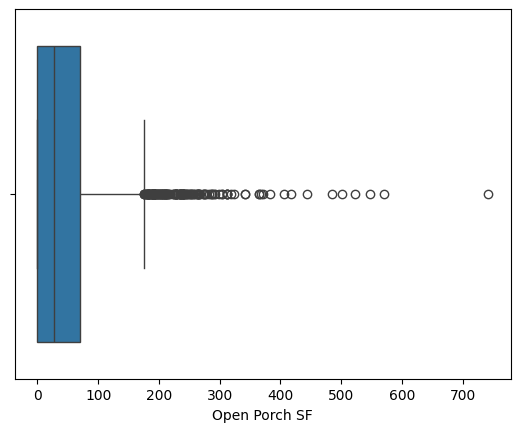

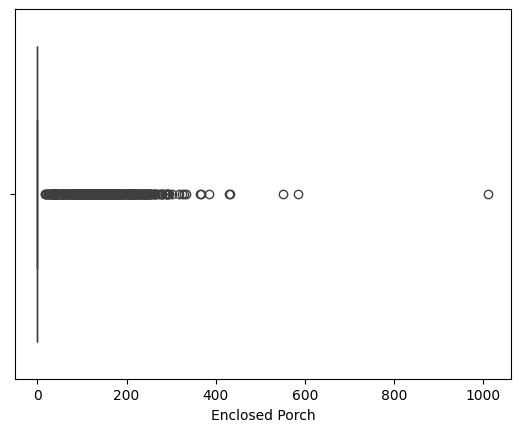

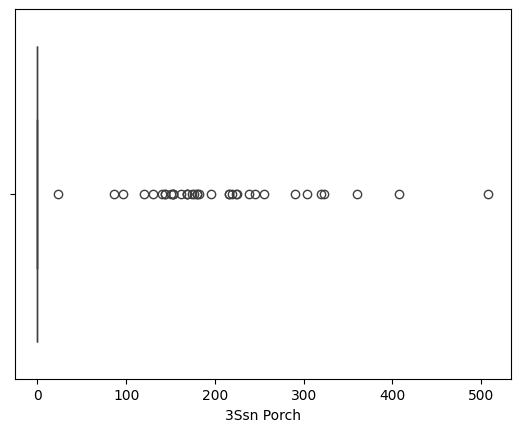

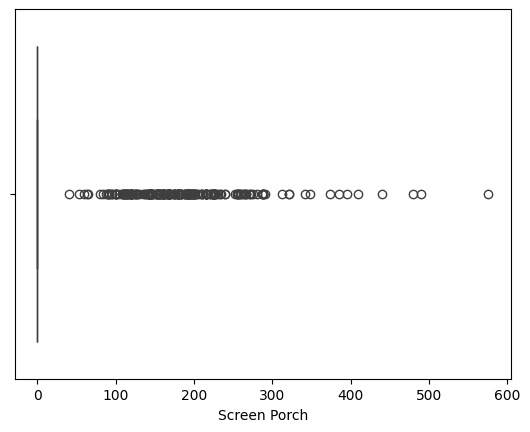

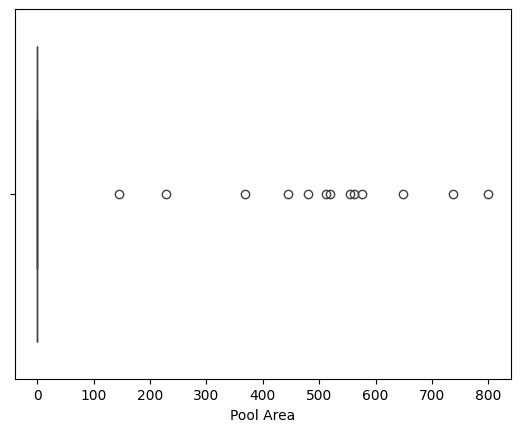

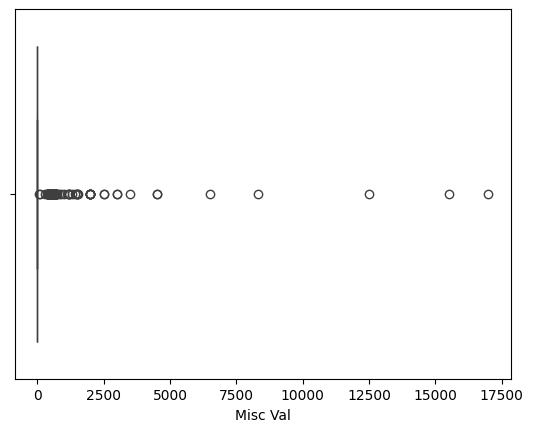

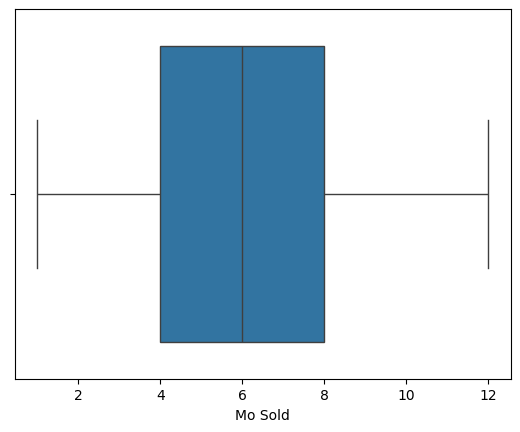

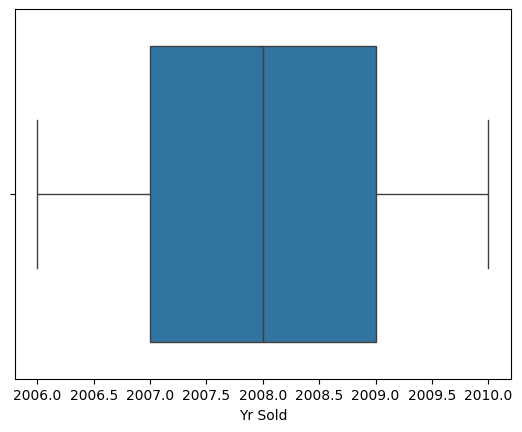

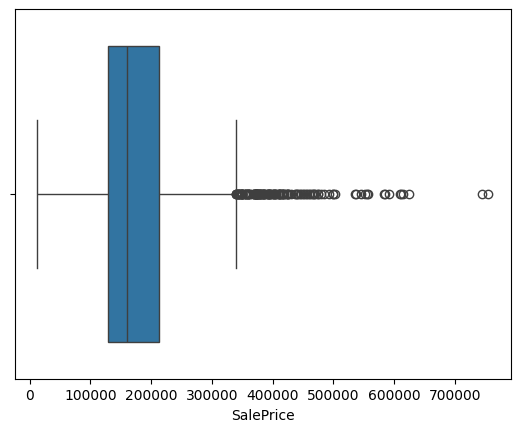

In [28]:
import warnings
warnings.filterwarnings("ignore")
for i in df.select_dtypes(include="number").columns:
    sns.boxplot(data=df, x=i)
    plt.show()

## Provide lot of outliers in the dataset.

In [29]:
df_num_vars= df.select_dtypes ( include='int64')

In [30]:
df_num_vars.columns

Index(['Order', 'PID', 'MS SubClass', 'Lot Area', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd',
       'Fireplaces', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch',
       '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold',
       'Yr Sold', 'SalePrice'],
      dtype='object')

## The output will be an Index object containing the names of all int64 columns in the dataset.

In [31]:
df_float_vars= df.select_dtypes (include='float')

In [32]:
df_float_vars.columns

Index(['Lot Frontage', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2',
       'Bsmt Unf SF', 'Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath',
       'Garage Yr Blt', 'Garage Cars', 'Garage Area'],
      dtype='object')

## The output will be an Index object containing the names of all float columns in the dataset.

In [33]:
def wisker(col):
    q1,q3 = np.percentile(col,[25,75])
    iqr =q3-q1
    lower_limit = q1-(1.5*iqr)
    upper_limit = q3+(1.5*iqr)

    return lower_limit, upper_limit

In [34]:
for i in ['Order', 'PID', 'MS SubClass', 'Lot Area', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd',
       'Fireplaces', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch',
       '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold',
       'Yr Sold', 'SalePrice', 'Lot Frontage', 'Mas Vnr Area',
        'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
        'Bsmt Full Bath', 'Bsmt Half Bath','Garage Yr Blt', 'Garage Cars',
          'Garage Area']:
    lower_limit, upper_limit = wisker(df[i])
    df[i] = np.where(df[i]<lower_limit, lower_limit, df[i])
    df[i] = np.where(df[i]>upper_limit, upper_limit, df[i])

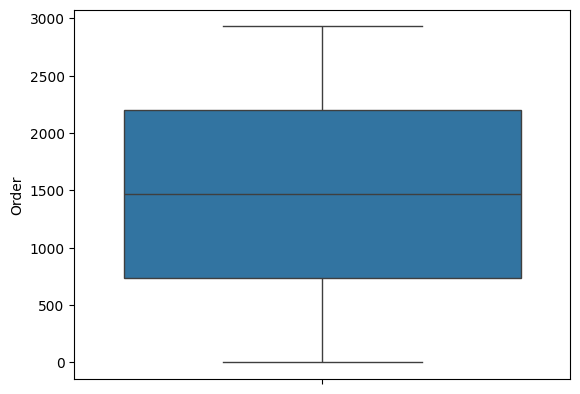

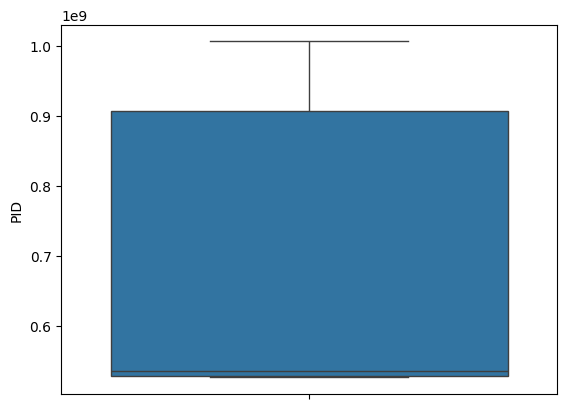

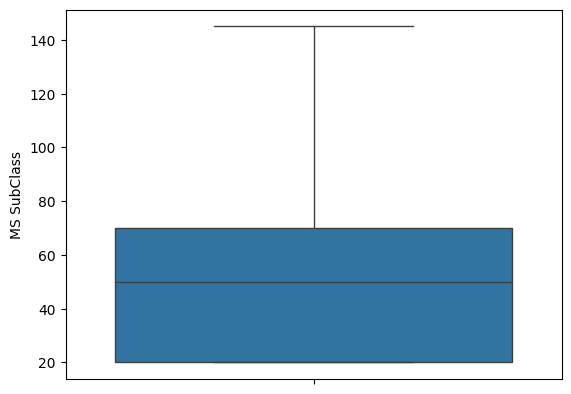

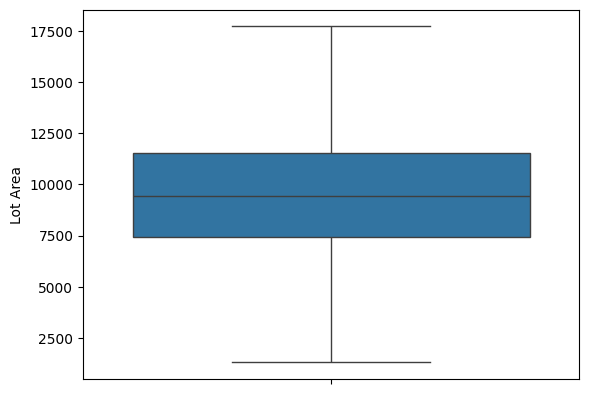

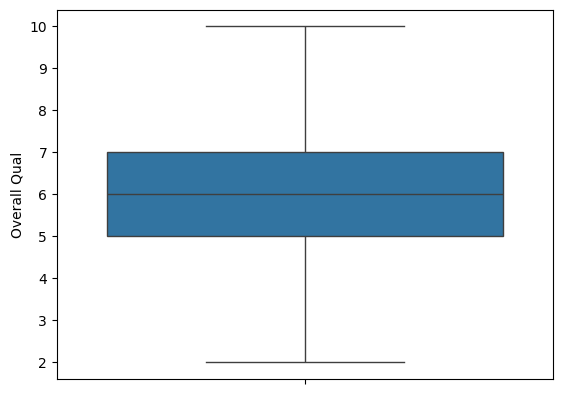

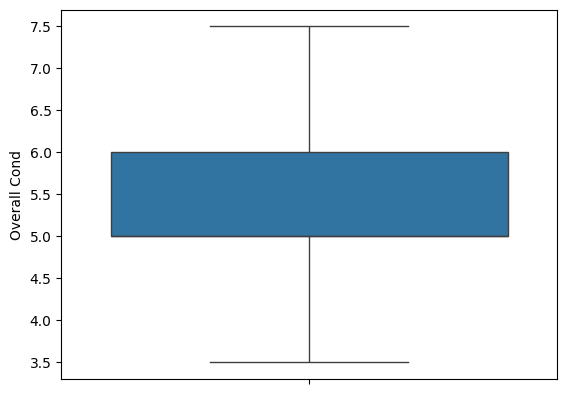

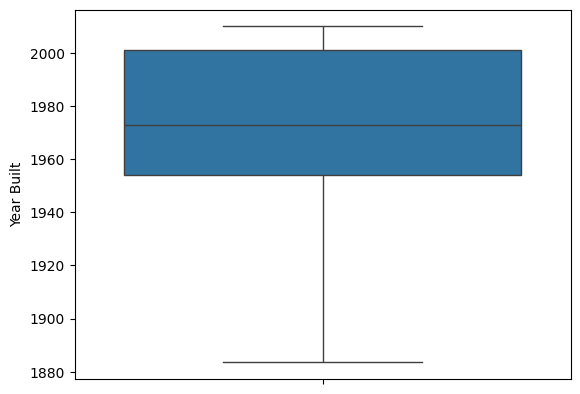

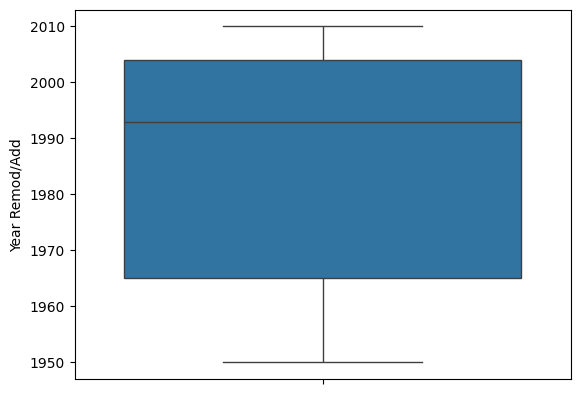

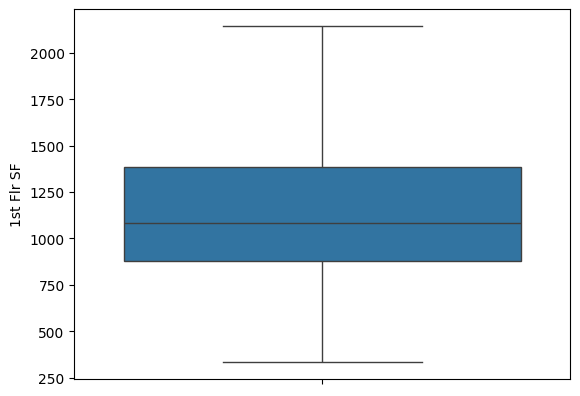

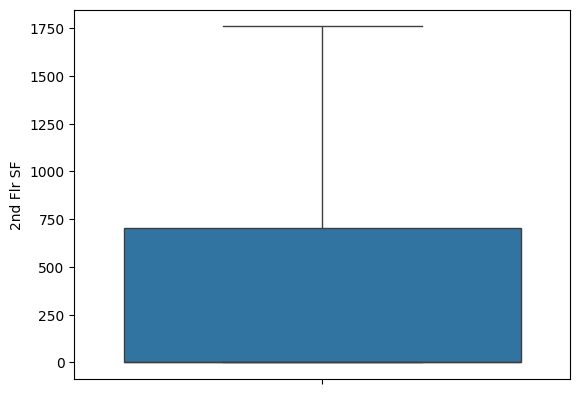

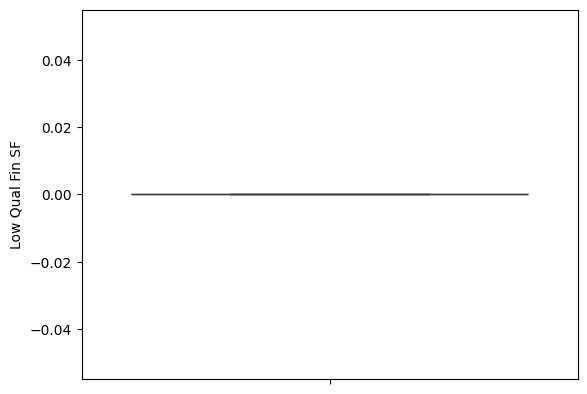

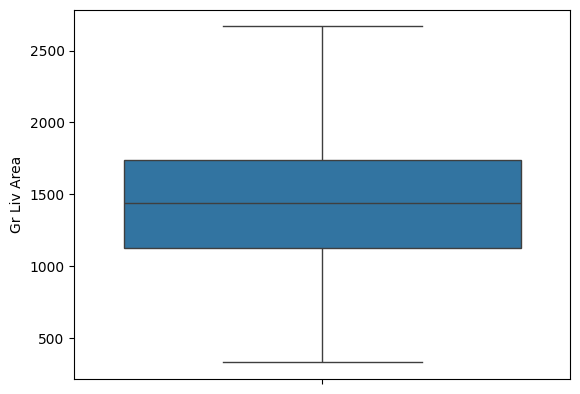

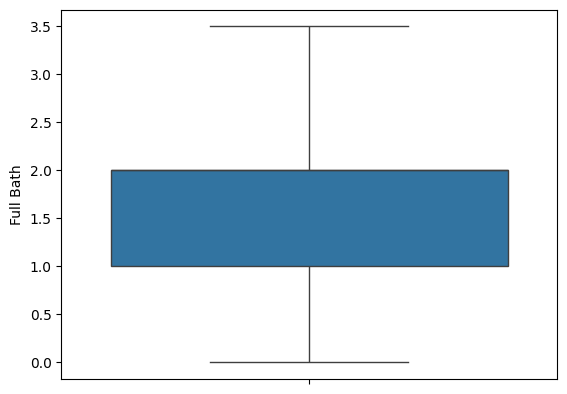

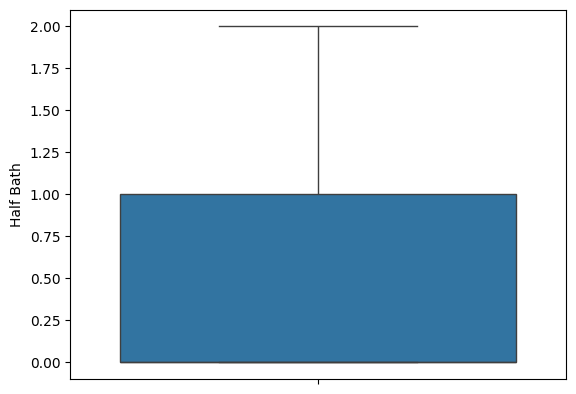

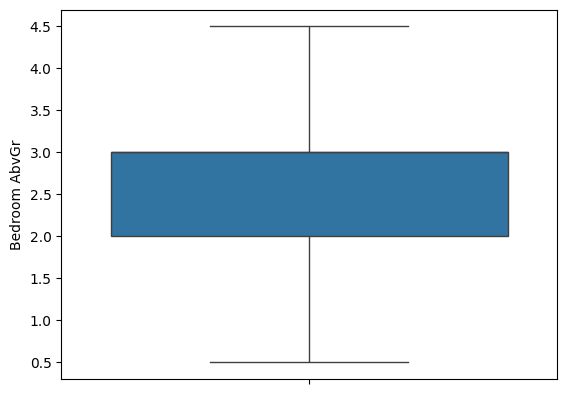

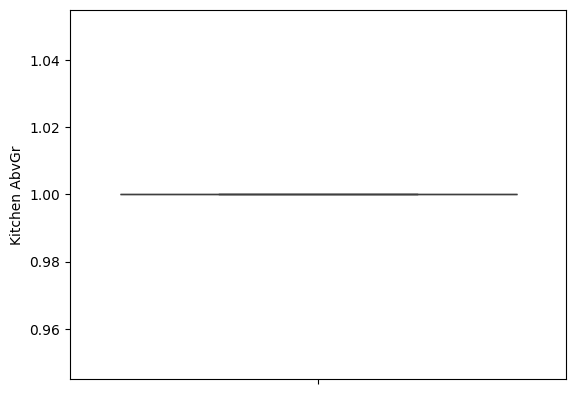

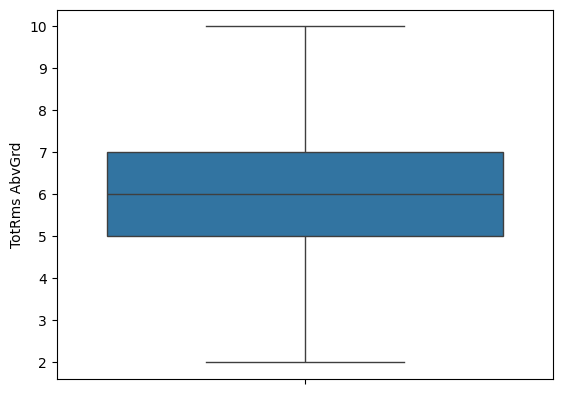

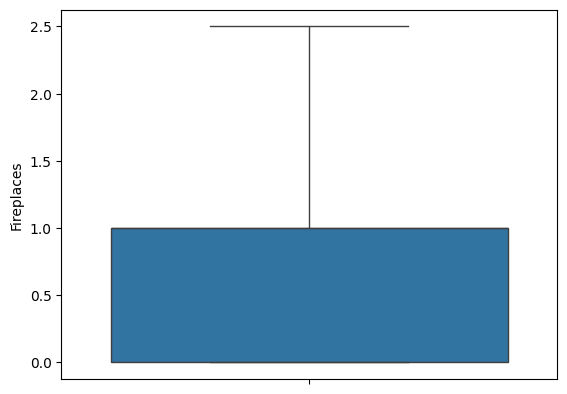

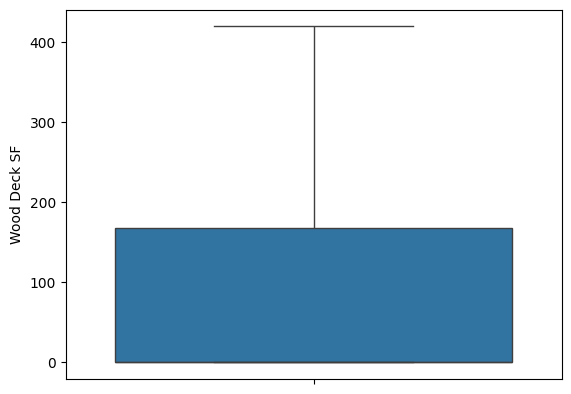

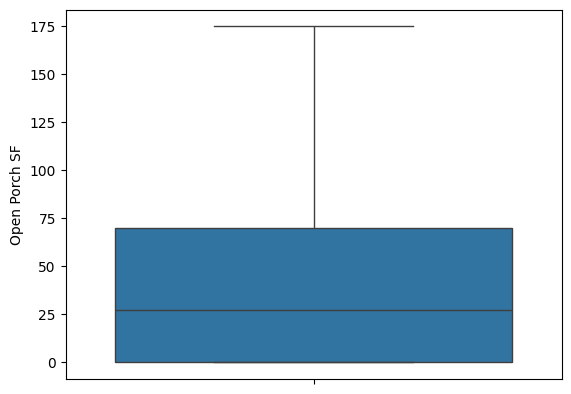

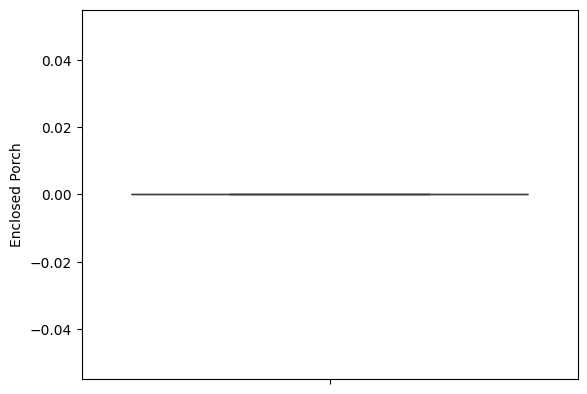

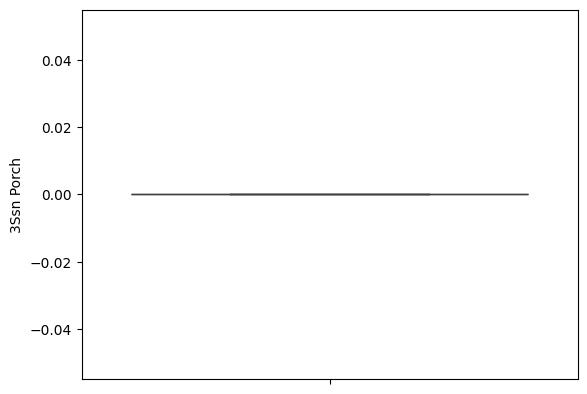

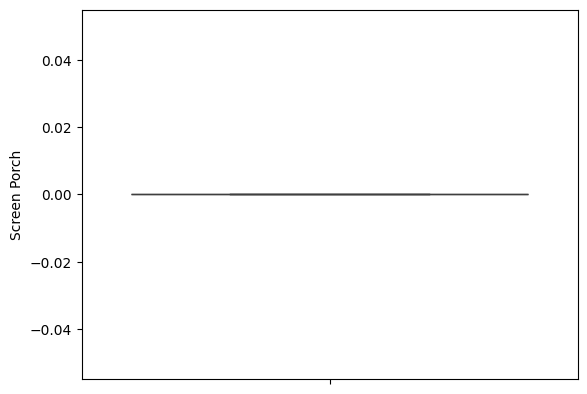

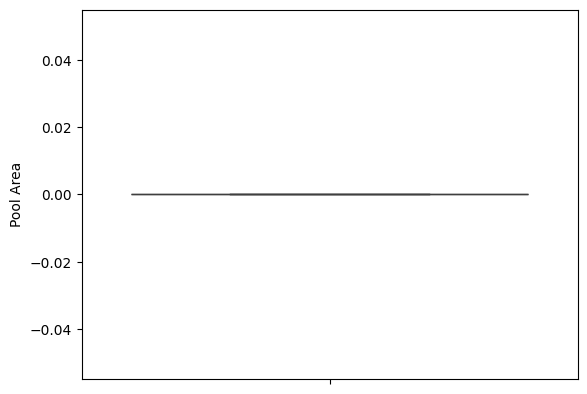

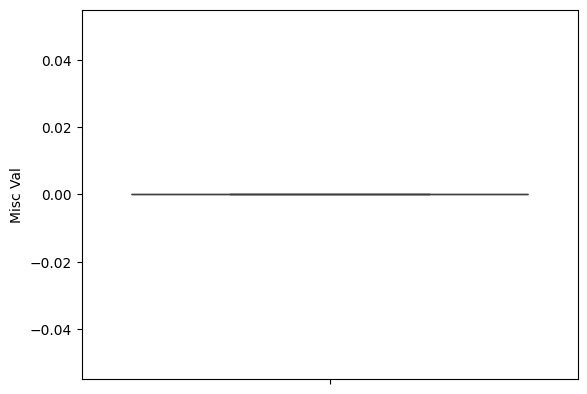

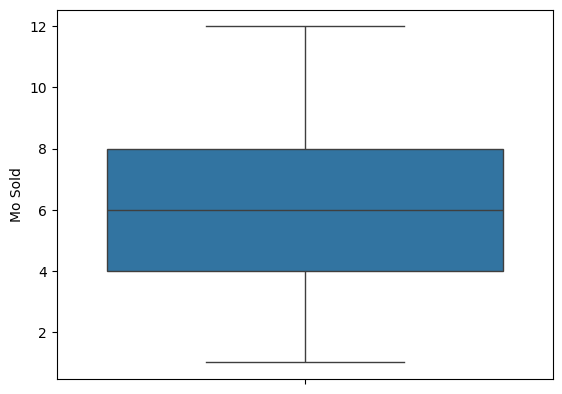

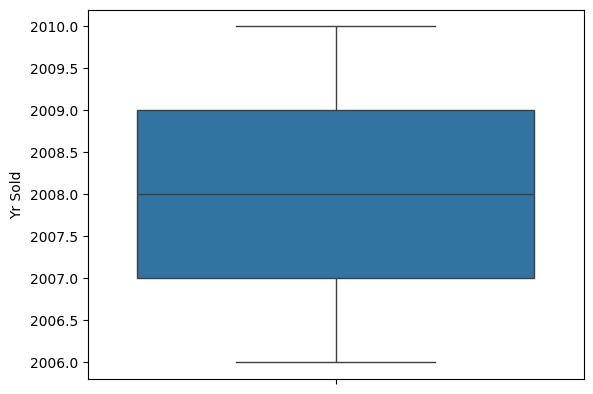

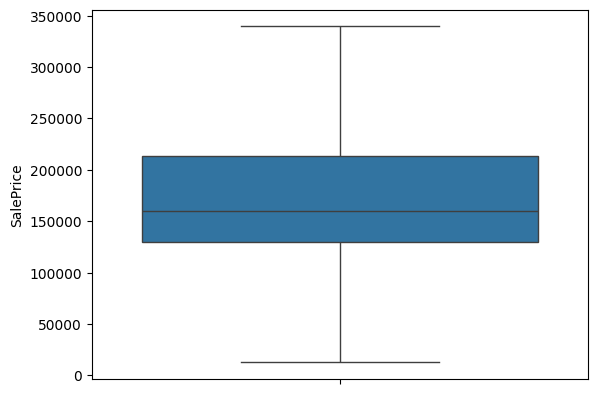

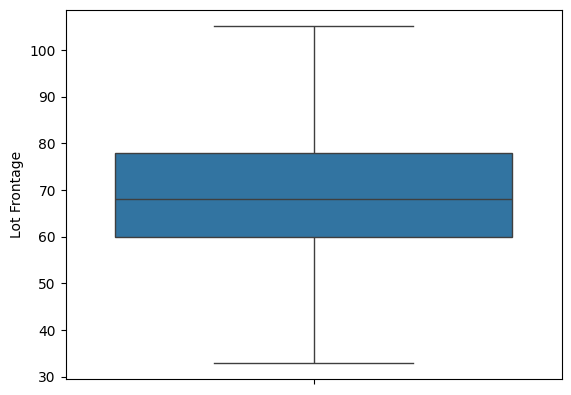

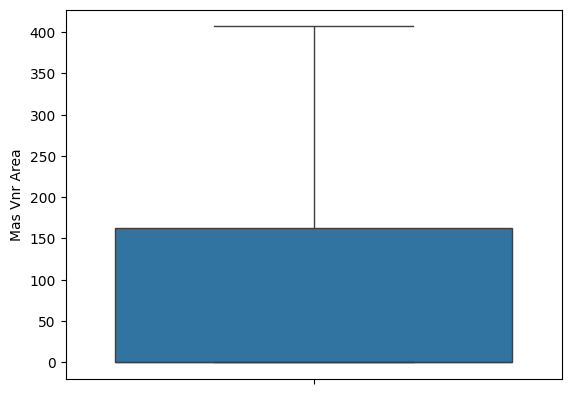

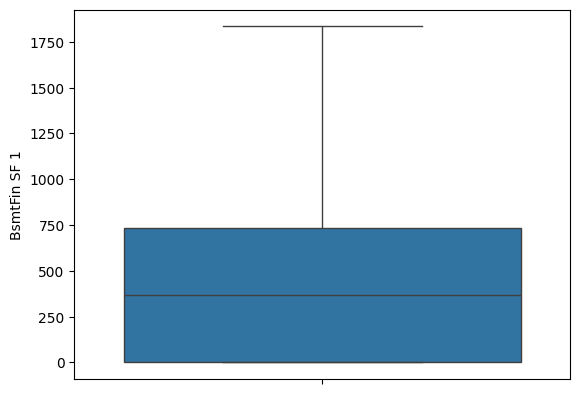

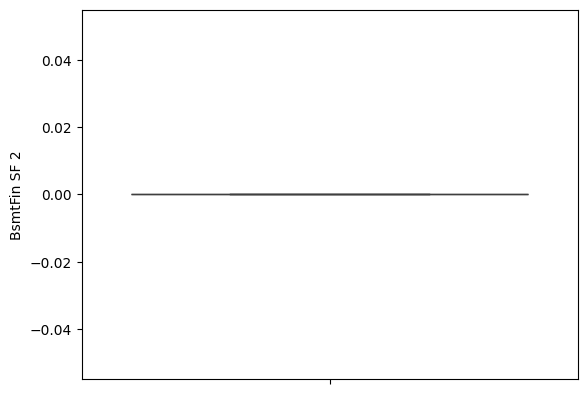

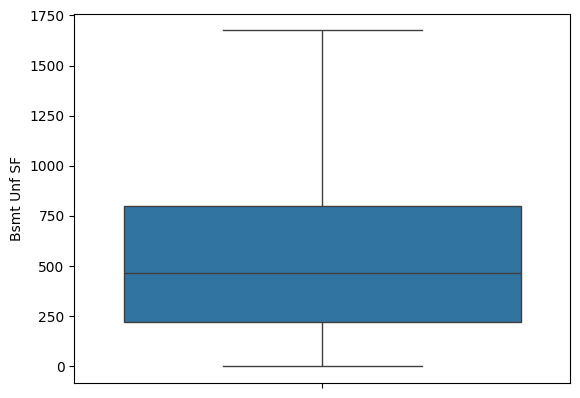

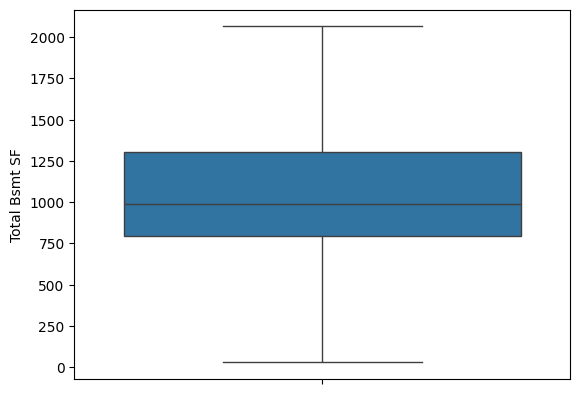

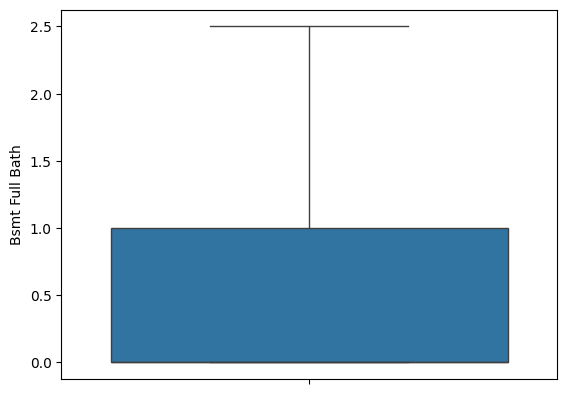

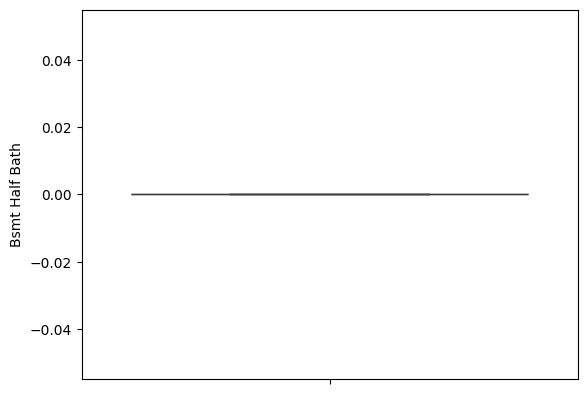

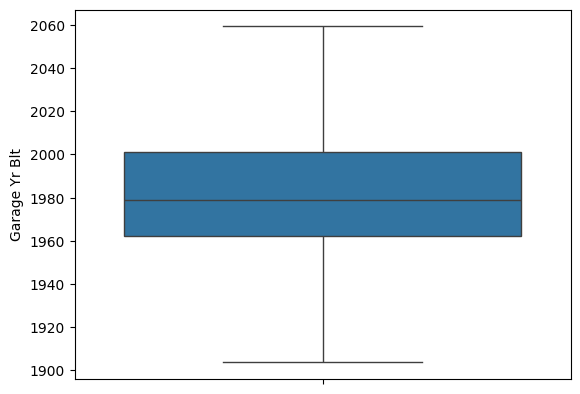

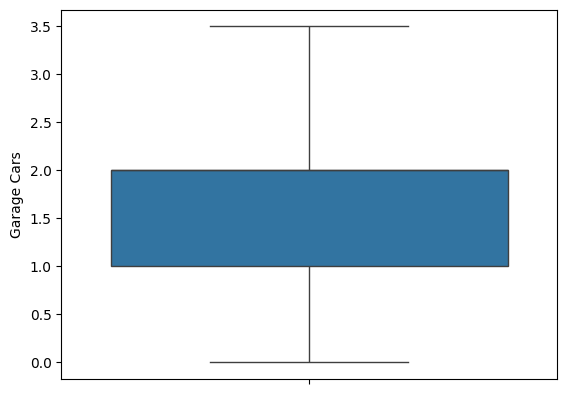

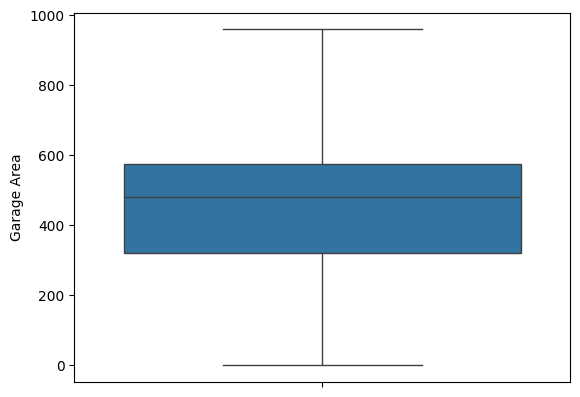

In [35]:
for i in ['Order', 'PID', 'MS SubClass', 'Lot Area', 'Overall Qual',
    'Overall Cond', 'Year Built', 'Year Remod/Add', '1st Flr SF',
    '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Full Bath',
    'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd',
    'Fireplaces', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch',
    '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold',
    'Yr Sold', 'SalePrice', 'Lot Frontage', 'Mas Vnr Area',
    'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
    'Bsmt Full Bath', 'Bsmt Half Bath', 'Garage Yr Blt', 'Garage Cars',
    'Garage Area']:
    sns.boxplot(df[i])
    plt.show()

## All outliers remove from this dataset.

In [37]:
df_cat_vars= df.select_dtypes (include='object')

In [38]:
df_cat_vars.columns

Index(['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour',
       'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
       'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature',
       'Sale Type', 'Sale Condition'],
      dtype='object')

In [39]:
df_cat_vars.shape

(2930, 43)

In [40]:
df_num_vars= df.select_dtypes (include='int64')

In [41]:
df_num_vars.shape

(2930, 0)

In [42]:
df_float_vars= df.select_dtypes (include='float')

In [43]:
df_float_vars

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
0,1.0,526301100.0,20.0,105.0,17727.75,6.0,5.0,1960.0,1960.0,112.0,...,210.0,62.0,0.0,0.0,0.0,0.0,0.0,5.0,2010.0,215000.0
1,2.0,526350040.0,20.0,80.0,11622.00,5.0,6.0,1961.0,1961.0,0.0,...,140.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,2010.0,105000.0
2,3.0,526351010.0,20.0,81.0,14267.00,6.0,6.0,1958.0,1958.0,108.0,...,393.0,36.0,0.0,0.0,0.0,0.0,0.0,6.0,2010.0,172000.0
3,4.0,526353030.0,20.0,93.0,11160.00,7.0,5.0,1968.0,1968.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,2010.0,244000.0
4,5.0,527105010.0,60.0,74.0,13830.00,5.0,5.0,1997.0,1998.0,0.0,...,212.0,34.0,0.0,0.0,0.0,0.0,0.0,3.0,2010.0,189900.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926.0,923275080.0,80.0,37.0,7937.00,6.0,6.0,1984.0,1984.0,0.0,...,120.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,2006.0,142500.0
2926,2927.0,923276100.0,20.0,68.0,8885.00,5.0,5.0,1983.0,1983.0,0.0,...,164.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,2006.0,131000.0
2927,2928.0,923400125.0,85.0,62.0,10441.00,5.0,5.0,1992.0,1992.0,0.0,...,80.0,32.0,0.0,0.0,0.0,0.0,0.0,7.0,2006.0,132000.0
2928,2929.0,924100070.0,20.0,77.0,10010.00,5.0,5.0,1974.0,1975.0,0.0,...,240.0,38.0,0.0,0.0,0.0,0.0,0.0,4.0,2006.0,170000.0


In [45]:
df_float_vars.shape

(2930, 39)

## Visualize target distribution (log-transform if skewed) with missing data & percentage

In [46]:
# Statistical transformations
from scipy import stats
from scipy.stats import norm, skew
import warnings
warnings.filterwarnings('ignore')

In [47]:
train, test = train_test_split(df, test_size=0.2, random_state=42)

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

Train shape: (2344, 82)
Test shape: (586, 82)


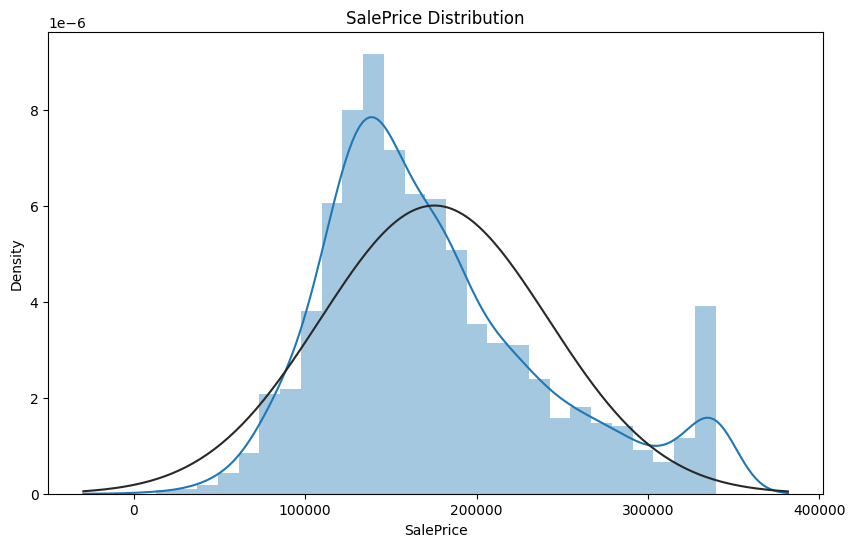

In [48]:
# Target variable analysis
plt.figure(figsize=(10,6))
sns.distplot(train['SalePrice'], fit=norm)
plt.title("SalePrice Distribution")
plt.show()

In [49]:
# Check skewness & kurtosis
print(f"Skewness: {train['SalePrice'].skew():.4f}")
print(f"Kurtosis: {train['SalePrice'].kurt():.4f}")

Skewness: 0.8292
Kurtosis: 0.2001



--- Dataset Information ---
            Order           PID  MS SubClass  Lot Frontage      Lot Area  \
count  2930.00000  2.930000e+03  2930.000000   2930.000000   2930.000000   
mean   1465.50000  7.144645e+08    55.585324     68.415017   9559.384044   
std     845.96247  1.887308e+08    37.943108     17.042927   3621.156578   
min       1.00000  5.263011e+08    20.000000     33.000000   1300.000000   
25%     733.25000  5.284770e+08    20.000000     60.000000   7440.250000   
50%    1465.50000  5.354536e+08    50.000000     68.000000   9436.500000   
75%    2197.75000  9.071811e+08    70.000000     78.000000  11555.250000   
max    2930.00000  1.007100e+09   145.000000    105.000000  17727.750000   

       Overall Qual  Overall Cond   Year Built  Year Remod/Add  Mas Vnr Area  \
count   2930.000000   2930.000000  2930.000000     2930.000000   2930.000000   
mean       6.096246      5.537201  1971.371160     1984.266553     87.449019   
std        1.406571      0.952158    30.200557

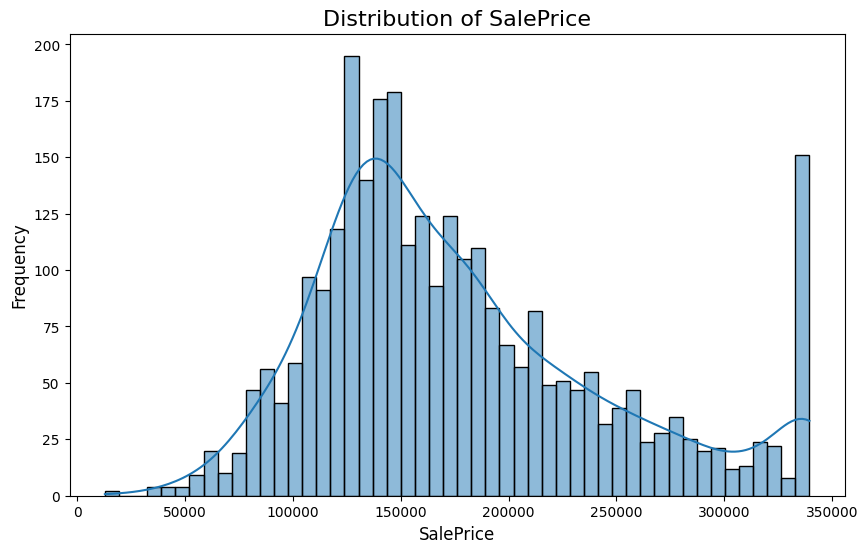


Skewness of SalePrice: 0.8052
Kurtosis of SalePrice: 0.0743


In [50]:
print("\n--- Dataset Information ---")
print(df.describe())

# Check for missing values
print("\n--- Missing Values ---")
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print(missing_values)

# Percentage of missing values
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
print("\n--- Percentage of Missing Values ---")
print(missing_percent)

# Visualize missing values (optional, for columns with significant missing data)
if not missing_values.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=missing_percent.index, y=missing_percent.values, palette='viridis')
    plt.title('Percentage of Missing Values per Feature', fontsize=16)
    plt.xlabel('Features', fontsize=12)
    plt.ylabel('Percentage Missing (%)', fontsize=12)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
else:
    print("\nNo missing values found.")

# ### Target Variable Analysis (`SalePrice`)
# Understanding the distribution of our target variable (`SalePrice`) is essential.
# We'll check its distribution and identify potential skewness.

plt.figure(figsize=(10, 6))
sns.histplot(df['SalePrice'], kde=True, bins=50)
plt.title('Distribution of SalePrice', fontsize=16)
plt.xlabel('SalePrice', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

# Check for skewness
print(f"\nSkewness of SalePrice: {df['SalePrice'].skew():.4f}")
print(f"Kurtosis of SalePrice: {df['SalePrice'].kurt():.4f}")

## Explore correlations between features and SalePrice

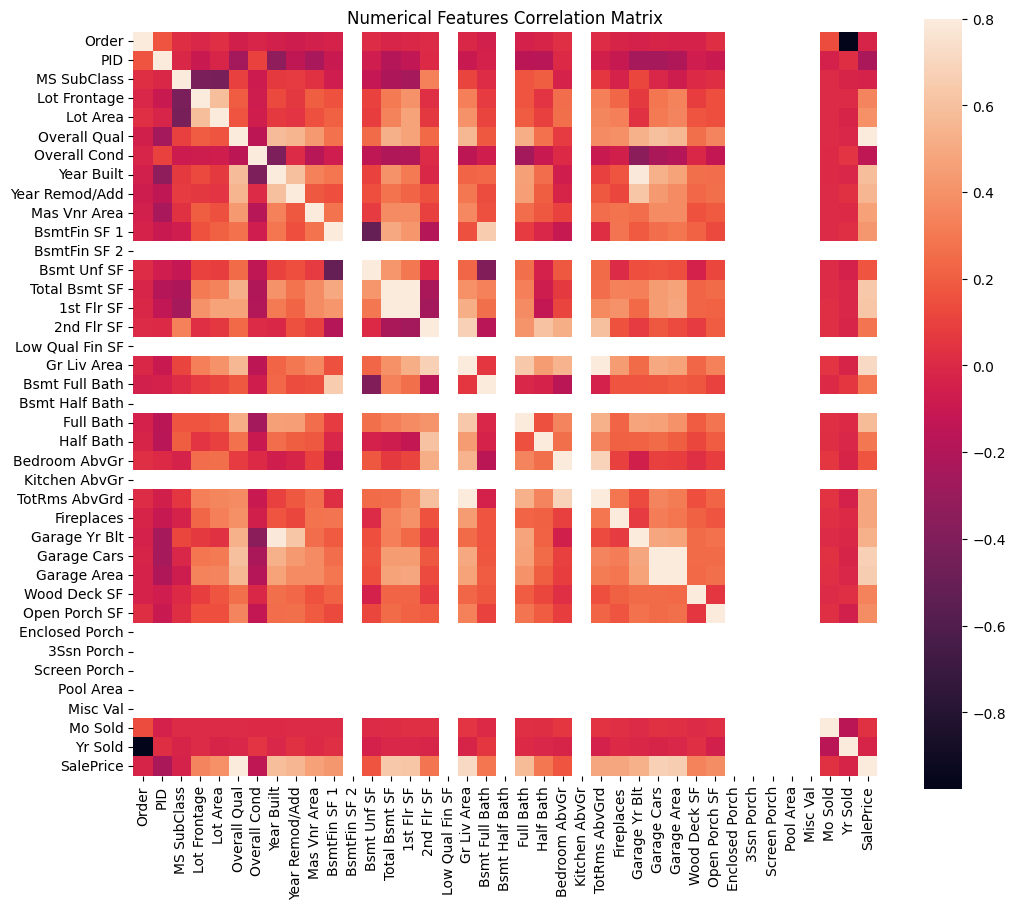

In [51]:
numerical_cols = train.select_dtypes(include=[np.number]).columns

# Create correlation matrix only for numerical features
corrmat = train[numerical_cols].corr()

# Plot the heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corrmat, vmax=0.8, square=True)
plt.title("Numerical Features Correlation Matrix")
plt.show()

In [52]:
# Select only numeric features
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix with SalePrice
correlation = numeric_df.corr()

# Sort correlations with SalePrice
corr_saleprice = correlation['SalePrice'].sort_values(ascending=False)
print(corr_saleprice)

SalePrice          1.000000
Overall Qual       0.822562
Gr Liv Area        0.726883
Garage Cars        0.682791
Garage Area        0.668274
Total Bsmt SF      0.648421
1st Flr SF         0.633557
Year Built         0.603326
Full Bath          0.577692
Year Remod/Add     0.575350
Garage Yr Blt      0.547851
TotRms AbvGrd      0.504171
Fireplaces         0.495083
Mas Vnr Area       0.479260
BsmtFin SF 1       0.424154
Lot Area           0.410429
Open Porch SF      0.392614
Lot Frontage       0.372086
Wood Deck SF       0.346891
Half Bath          0.294733
Bsmt Full Bath     0.279228
2nd Flr SF         0.276149
Bsmt Unf SF        0.189648
Bedroom AbvGr      0.168063
Mo Sold            0.045888
Yr Sold           -0.029198
Order             -0.031671
MS SubClass       -0.055750
Overall Cond      -0.137873
PID               -0.247214
BsmtFin SF 2            NaN
Low Qual Fin SF         NaN
Bsmt Half Bath          NaN
Kitchen AbvGr           NaN
Enclosed Porch          NaN
3Ssn Porch          

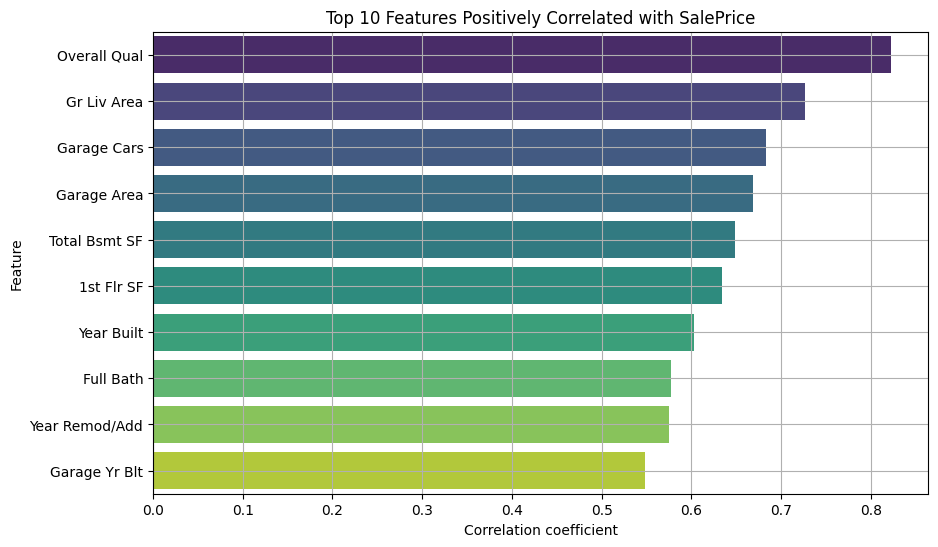

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 positive correlations
top_corr = corr_saleprice.drop('SalePrice').head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_corr.values, y=top_corr.index, palette='viridis')
plt.title("Top 10 Features Positively Correlated with SalePrice")
plt.xlabel("Correlation coefficient")
plt.ylabel("Feature")
plt.grid(True)
plt.show()

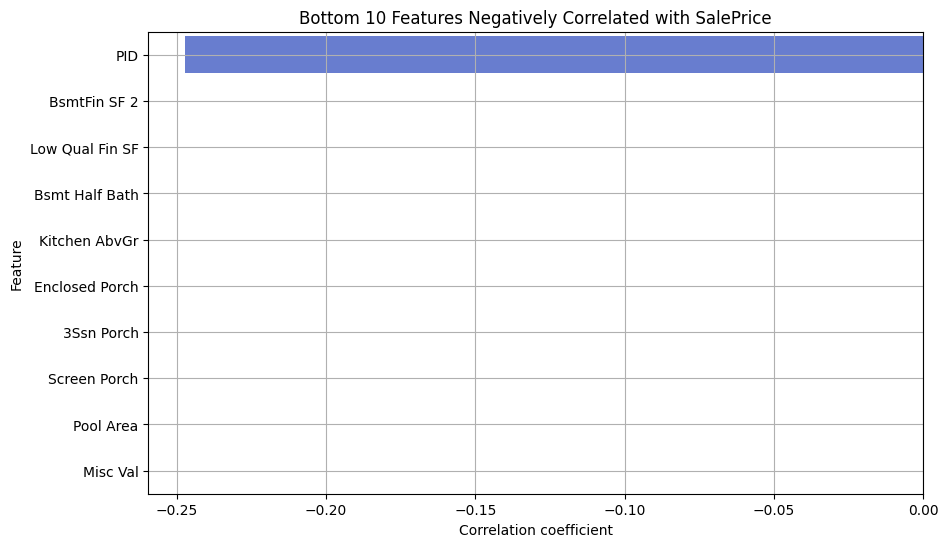

In [54]:
# Bottom 10 negative correlations
bottom_corr = corr_saleprice.tail(10)

plt.figure(figsize=(10,6))
sns.barplot(x=bottom_corr.values, y=bottom_corr.index, palette='coolwarm')
plt.title("Bottom 10 Features Negatively Correlated with SalePrice")
plt.xlabel("Correlation coefficient")
plt.ylabel("Feature")
plt.grid(True)
plt.show()

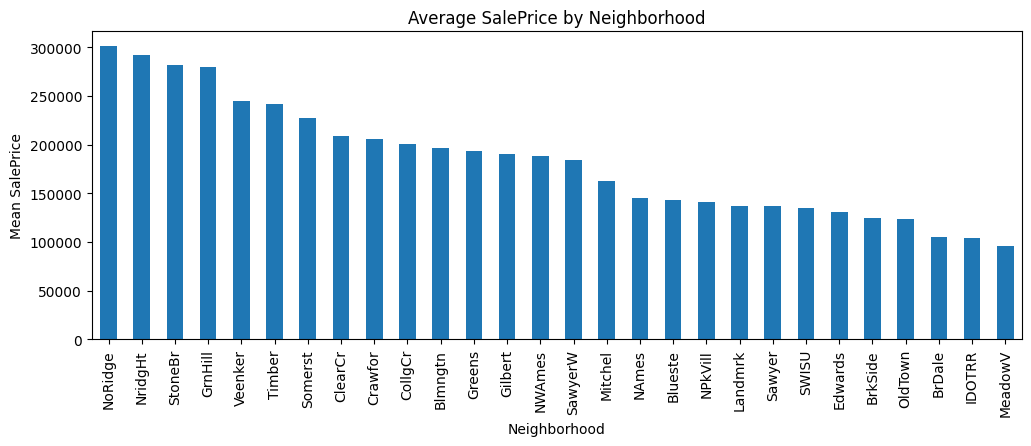

In [55]:
# Example: Neighborhood vs. SalePrice
df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(12,4))
plt.title("Average SalePrice by Neighborhood")
plt.ylabel("Mean SalePrice")
plt.xticks(rotation=90)
plt.show()

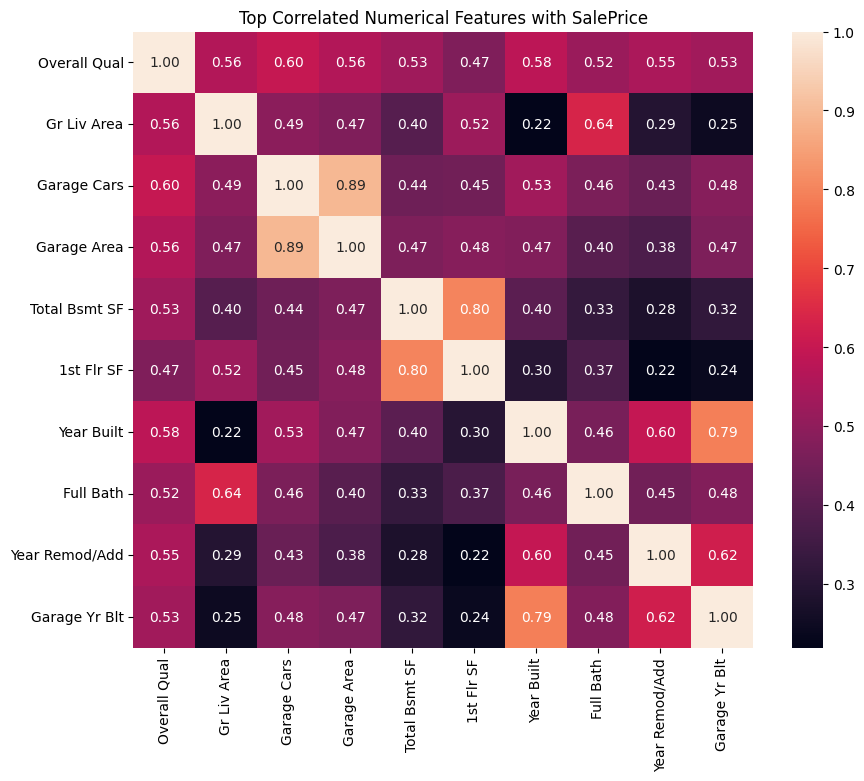

In [56]:
# Top correlated numerical features with SalePrice
top_corr = corrmat['SalePrice'].sort_values(ascending=False).head(11).index
top_corr = top_corr.drop('SalePrice')  # Remove SalePrice itself

# Plot top correlations
plt.figure(figsize=(10,8))
sns.heatmap(train[top_corr].corr(), annot=True, fmt='.2f')
plt.title("Top Correlated Numerical Features with SalePrice")
plt.show()

## Plot heatmaps, scatterplots (e.g., GrLivArea vs SalePrice)

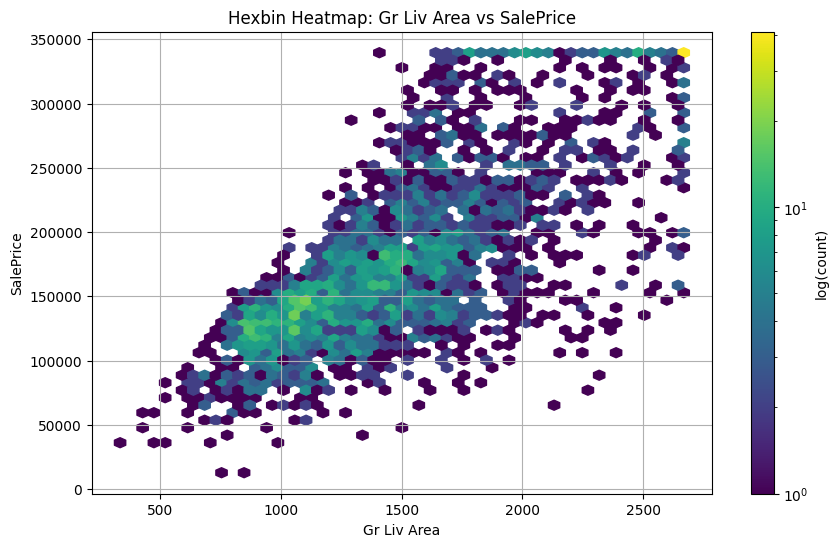

In [57]:
plt.figure(figsize=(10, 6))
plt.hexbin(df["Gr Liv Area"], df["SalePrice"], gridsize=50, cmap='viridis', bins='log')
plt.colorbar(label='log(count)')
plt.xlabel("Gr Liv Area")
plt.ylabel("SalePrice")
plt.title("Hexbin Heatmap: Gr Liv Area vs SalePrice")
plt.grid(True)
plt.show()

<Axes: xlabel='Gr Liv Area', ylabel='SalePrice'>

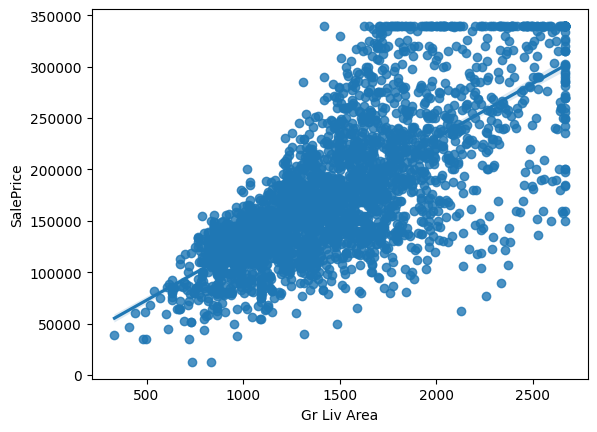

In [58]:
sns.regplot(x="Gr Liv Area", y="SalePrice", data=df)

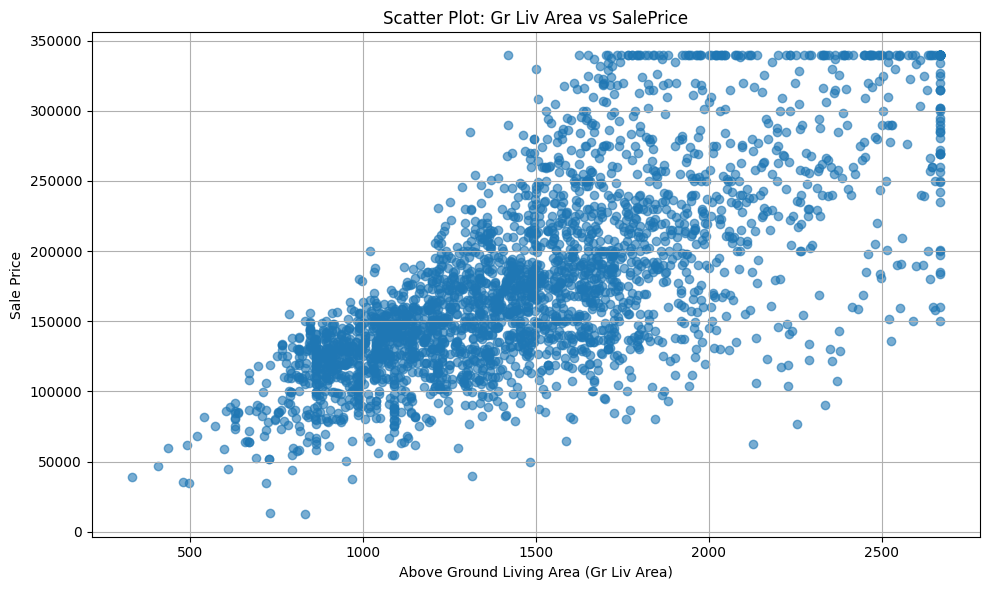

In [59]:
# 2. Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df["Gr Liv Area"], df["SalePrice"], alpha=0.6)
plt.xlabel("Above Ground Living Area (Gr Liv Area)")
plt.ylabel("Sale Price")
plt.title("Scatter Plot: Gr Liv Area vs SalePrice")
plt.grid(True)

# 3. Show the plot
plt.tight_layout()
plt.show()

## Feature engineering ideas

In [60]:
# Feature 1: House Age
df['HouseAge'] = df['Yr Sold'] - df['Year Built']

# Feature 2: Total square footage (above + basement)
df['TotalSF'] = df['Gr Liv Area'] + df['Total Bsmt SF']

# Display new features
print(df[['HouseAge', 'TotalSF']].head())

   HouseAge  TotalSF
0      50.0  2736.00
1      49.0  1778.00
2      52.0  2658.00
3      42.0  4174.25
4      13.0  2557.00


# Feature Selection

In [61]:
df.columns

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

In [62]:
# Create a target variable
X = df.drop(['SalePrice'], axis = 1)
y = df['SalePrice']

In [63]:
X.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,HouseAge,TotalSF
0,1.0,526301100.0,20.0,RL,105.0,17727.75,Pave,Grvl,IR1,Lvl,...,Ex,MnPrv,Shed,0.0,5.0,2010.0,WD,Normal,50.0,2736.00
1,2.0,526350040.0,20.0,RH,80.0,11622.00,Pave,Grvl,Reg,Lvl,...,Ex,MnPrv,Shed,0.0,6.0,2010.0,WD,Normal,49.0,1778.00
2,3.0,526351010.0,20.0,RL,81.0,14267.00,Pave,Grvl,IR1,Lvl,...,Ex,MnPrv,Gar2,0.0,6.0,2010.0,WD,Normal,52.0,2658.00
3,4.0,526353030.0,20.0,RL,93.0,11160.00,Pave,Grvl,Reg,Lvl,...,Ex,MnPrv,Shed,0.0,4.0,2010.0,WD,Normal,42.0,4174.25
4,5.0,527105010.0,60.0,RL,74.0,13830.00,Pave,Grvl,IR1,Lvl,...,Ex,MnPrv,Shed,0.0,3.0,2010.0,WD,Normal,13.0,2557.00


In [64]:
y.head()

,SalePrice
0,215000.0
1,105000.0
2,172000.0
3,244000.0
4,189900.0


In [65]:
df['SalePrice'].value_counts()

,count
SalePrice,
339500.0,137
135000.0,34
140000.0,33
130000.0,29
155000.0,28
...,...
247900.0,1
287500.0,1
284500.0,1


In [66]:
X.shape

(2930, 83)

In [67]:
y.shape

(2930,)

In [68]:
print(y)

0       215000.0
1       105000.0
2       172000.0
3       244000.0
4       189900.0
          ...   
2925    142500.0
2926    131000.0
2927    132000.0
2928    170000.0
2929    188000.0
Name: SalePrice, Length: 2930, dtype: float64


In [69]:
print(X)

       Order          PID  MS SubClass MS Zoning  Lot Frontage  Lot Area  \
0        1.0  526301100.0         20.0        RL         105.0  17727.75   
1        2.0  526350040.0         20.0        RH          80.0  11622.00   
2        3.0  526351010.0         20.0        RL          81.0  14267.00   
3        4.0  526353030.0         20.0        RL          93.0  11160.00   
4        5.0  527105010.0         60.0        RL          74.0  13830.00   
...      ...          ...          ...       ...           ...       ...   
2925  2926.0  923275080.0         80.0        RL          37.0   7937.00   
2926  2927.0  923276100.0         20.0        RL          68.0   8885.00   
2927  2928.0  923400125.0         85.0        RL          62.0  10441.00   
2928  2929.0  924100070.0         20.0        RL          77.0  10010.00   
2929  2930.0  924151050.0         60.0        RL          74.0   9627.00   

     Street Alley Lot Shape Land Contour  ... Pool QC  Fence Misc Feature  \
0      Pav

## Feature Importance

In [70]:
import pandas as pd
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split

# Optional: one-hot encode if you have categorical features
X = pd.get_dummies(X, drop_first=True)

# Fit ExtraTreesClassifier
model = ExtraTreesClassifier()
model.fit(X, y)

# Get feature importances
importances = model.feature_importances_

# Display feature importances with names
feature_importances = pd.Series(importances, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)

# Print top features
print("Feature Importances:")
print(feature_importances.head(10))

Feature Importances:
TotalSF          0.024640
Order            0.023694
Gr Liv Area      0.023169
1st Flr SF       0.022253
PID              0.022128
Garage Area      0.022010
Lot Area         0.021907
Bsmt Unf SF      0.021738
Total Bsmt SF    0.021603
Mo Sold          0.020926
dtype: float64


In [71]:
from sklearn.ensemble import RandomForestRegressor

# Fit model
model = RandomForestRegressor()
model.fit(X, y)

# Get feature importances
importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)
print("Top features:\n", top_features)

Top features:
 Overall Qual      0.482784
TotalSF           0.328390
HouseAge          0.016753
Gr Liv Area       0.013294
Garage Cars       0.011282
Lot Area          0.009849
Year Remod/Add    0.009807
Bsmt Unf SF       0.009042
Garage Area       0.008763
BsmtFin SF 1      0.008335
dtype: float64


## Splitting Dataset

In [72]:
from sklearn.model_selection  import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 80)

In [73]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier  # or any model
import numpy as np

# Initialize model
model = RandomForestClassifier()

# Define 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate model using cross-validation
scores = cross_val_score(model, X, y, cv=kf)

# Print results
print("Cross-validation scores:", scores)
print("Mean accuracy:", np.mean(scores))

Cross-validation scores: [0.08191126 0.04607509 0.06484642 0.06313993 0.06143345]
Mean accuracy: 0.06348122866894197


# Feature scaling (StandardScaler or RobustScaler).

In [74]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train2 = pd.DataFrame(sc.fit_transform(X_train))
X_test2 = pd.DataFrame(sc.transform(X_test))
X_train2.columns = X_train.columns.values
X_test2.columns = X_test.columns.values
X_train2.index = X_train.index.values
X_test2.index = X_test.index.values
X_train = X_train2
X_test = X_test2

# Using Principal Dimensional Reduction

In [75]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 4)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)
explained_variance = pca.explained_variance_ratio_
print(pd.DataFrame(explained_variance))

          0
0  0.069927
1  0.029517
2  0.023522
3  0.020635


# Linear Regression

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # RMSE
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 22859.30
Root Mean Squared Error (RMSE): 30124.15
R² Score: 0.8144


## Ridge Regression

In [81]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
import numpy as np

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Ridge Regression model
model = Ridge(alpha=1.0)
Lasso(alpha=0.1)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # RMSE
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 12862.98
Root Mean Squared Error (RMSE): 18510.77
R² Score: 0.9357


## Lasso Regression

In [83]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
import numpy as np # Import numpy for np.sqrt

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Lasso Regression model
model = Lasso(alpha=0.1)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # RMSE
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 13340.99
Root Mean Squared Error (RMSE): 20700.47
R² Score: 0.9196


## DecisionTreeClassifier

In [85]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor # Changed from DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = DecisionTreeRegressor(random_state=42) # Removed 'criterion' as it's for classification
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # RMSE: changed to np.sqrt()
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 20513.77
Root Mean Squared Error (RMSE): 30020.37
R² Score: 0.8309


## Random Forest Regressor

In [87]:
import numpy as np # Import numpy for np.sqrt
from sklearn.ensemble import RandomForestRegressor # Changed from RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model2 = RandomForestRegressor(n_estimators=100, random_state=42) # Use Regressor
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred2) # Use y_pred2
rmse = np.sqrt(mean_squared_error(y_test, y_pred2))  # RMSE: changed to np.sqrt()
r2 = r2_score(y_test, y_pred2) # Use y_pred2

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 12940.11
Root Mean Squared Error (RMSE): 18359.03
R² Score: 0.9368


# XGBoost Regressor

In [89]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np # Import numpy for np.sqrt

# Train Support Vector Regression(SVR) model
model =  XGBRegressor(objective='reg:squarederror', random_state=42)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # RMSE: changed to np.sqrt()
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 12758.48
Root Mean Squared Error (RMSE): 18139.33
R² Score: 0.9383


## LightGBM Regressor

In [90]:
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Create and train LightGBM model
model = lgb.LGBMRegressor(random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # RMSE: changed to np.sqrt()
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003328 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4227
[LightGBM] [Info] Number of data points in the train set: 2344, number of used features: 175
[LightGBM] [Info] Start training from score 175384.102816
Mean Absolute Error (MAE): 11685.86
Root Mean Squared Error (RMSE): 16707.91
R² Score: 0.9476


## Visualize

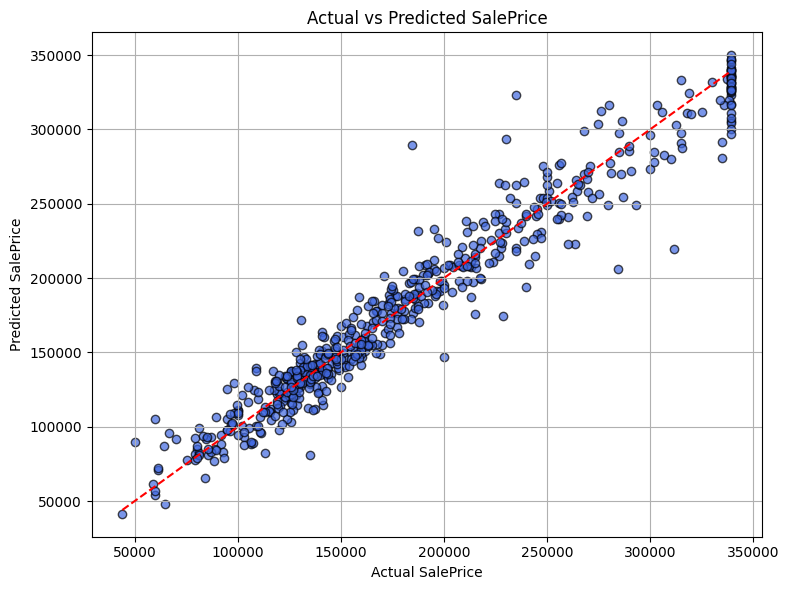

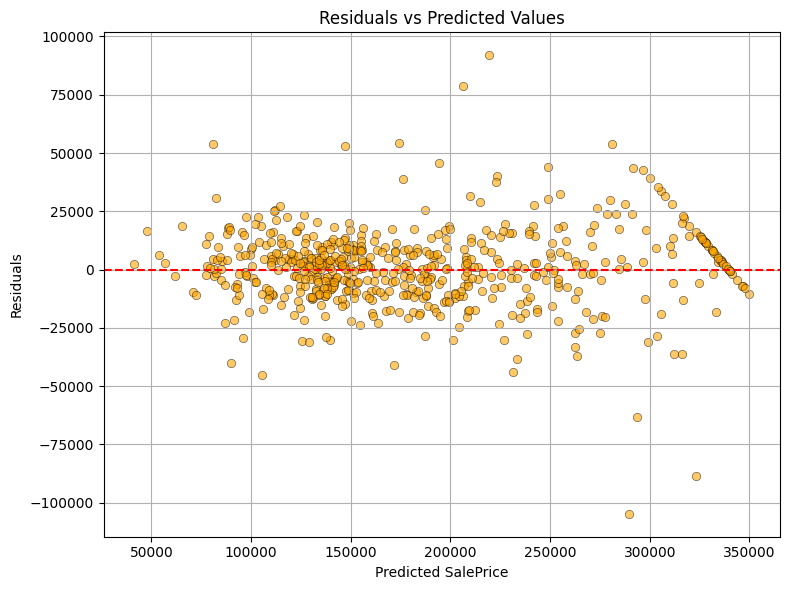

In [91]:
# Scatter plot of actual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='royalblue', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect line
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted SalePrice")
plt.grid(True)
plt.tight_layout()
plt.show()

## Residual Plot

residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6, color="orange", edgecolor="k")
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted SalePrice")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.grid(True)
plt.tight_layout()
plt.show()

# VotingRegressor

In [92]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define base regressors
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)
gbr = GradientBoostingRegressor(n_estimators=100, random_state=42)

# Combine them using VotingRegressor
voting_reg = VotingRegressor(estimators=[
    ('lr', lr),
    ('rf', rf),
    ('gbr', gbr)
])

# Fit the model
voting_reg.fit(X_train, y_train)

# Predict
y_pred = voting_reg.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # RMSE: changed to np.sqrt()
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")


MAE: 11349.38
RMSE: 16206.38
R² Score: 0.9507


# StackingRegressor (e.g., base = DT, RF, SVR; meta = Ridge)

In [94]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Scale features (important for SVR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define base models
base_models = [
    ('dt', DecisionTreeRegressor(random_state=42)),
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('svr', SVR(kernel='rbf', C=100))
]

# Meta model
meta_model = Ridge(alpha=1.0)

# Define stacking regressor
stacking_reg = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    passthrough=False,
    cv=5
)

# Fit model
stacking_reg.fit(X_train_scaled, y_train)

# Predict
y_pred = stacking_reg.predict(X_test_scaled)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # Added np.sqrt for RMSE
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

MAE: 12895.82
RMSE: 18403.17
R² Score: 0.9364


## Top 10 most important features

In [95]:
from sklearn.feature_selection import SelectKBest, f_regression

# Drop non-numeric/categorical columns first
df_numeric = df.select_dtypes(include=['number']).dropna()

X = df_numeric.drop('SalePrice', axis=1)
y = df_numeric['SalePrice']

# Select top 10 features
selector = SelectKBest(score_func=f_regression, k=10)
X_selected = selector.fit_transform(X, y)

# Get column names
selected_cols = X.columns[selector.get_support()]
print("Top 10 selected features:", list(selected_cols))

Top 10 selected features: ['Overall Qual', 'Year Built', 'Total Bsmt SF', '1st Flr SF', 'Gr Liv Area', 'Full Bath', 'Garage Cars', 'Garage Area', 'HouseAge', 'TotalSF']


           feature  shap_importance
39         TotalSF     20835.710938
5     Overall Qual     20197.507812
8   Year Remod/Add      4560.174805
7       Year Built      3526.463379
25      Fireplaces      3099.102051
6     Overall Cond      3053.830566
17     Gr Liv Area      2574.908203
10    BsmtFin SF 1      2375.723389
4         Lot Area      2329.056396
38        HouseAge      2281.796143


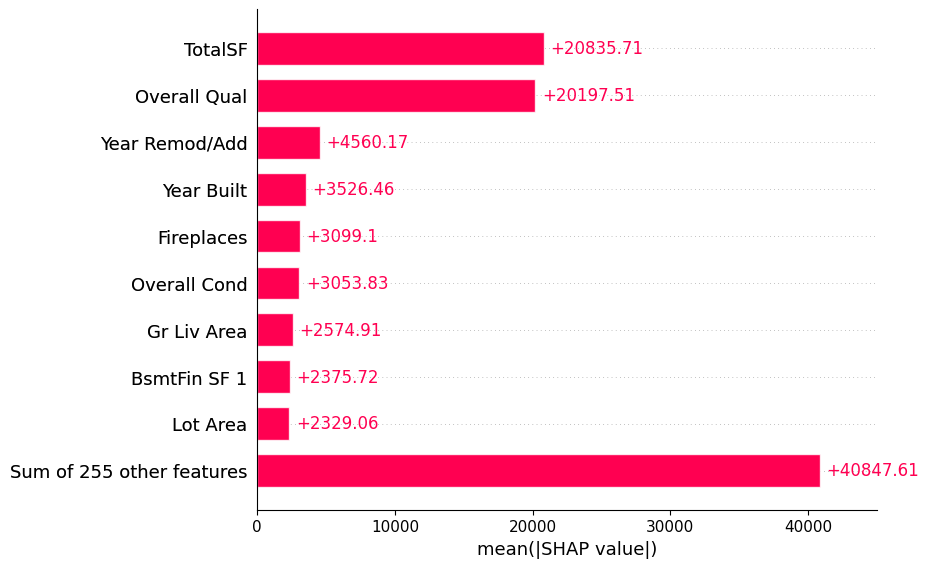

In [97]:
import pandas as pd
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split

# 2. Preprocess: Drop rows with NA and encode categoricals
df = df.dropna() # Keeping this as per the original cell for consistency
# One-hot encode categorical features using pd.get_dummies
df = pd.get_dummies(df, drop_first=True)

# 3. Split features and target
X = df.drop(columns='SalePrice')
y = df['SalePrice']
# 4. Train-test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train a model
model = xgb.XGBRegressor(n_estimators=100, max_depth=4, random_state=42)
model.fit(X_train, y_train)

# 6. Use SHAP
explainer = shap.Explainer(model)
shap_values = explainer(X_train)

# 7. Get mean absolute SHAP values for each feature
shap_sum = np.abs(shap_values.values).mean(axis=0)
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'shap_importance': shap_sum
}).sort_values(by='shap_importance', ascending=False)

# 8. Display top 10 features
top_10 = importance_df.head(10)
print(top_10)


# 9. Optional: Visualize
shap.plots.bar(shap_values, max_display=10)

### Vizualization By Using SHAP

In [103]:
import xgboost as xgb
import pandas as pd
import shap
import numpy as np

model = xgb.XGBRegressor(random_state=42)
model.fit(X_train, y_train)

# Ensure all columns in X_train and X_test are explicitly numeric (float64).
# Use apply(pd.to_numeric, errors='coerce') to handle any lingering non-numeric types
# by converting them to NaN, then fill NaN values.
X_train_processed = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test_processed = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)

# Finally, ensure explicit float64 type for SHAP compatibility
X_train_processed = X_train_processed.astype(np.float64)
X_test_processed = X_test_processed.astype(np.float64)

explainer = shap.Explainer(model, X_train_processed)
shap_values = explainer(X_test_processed)

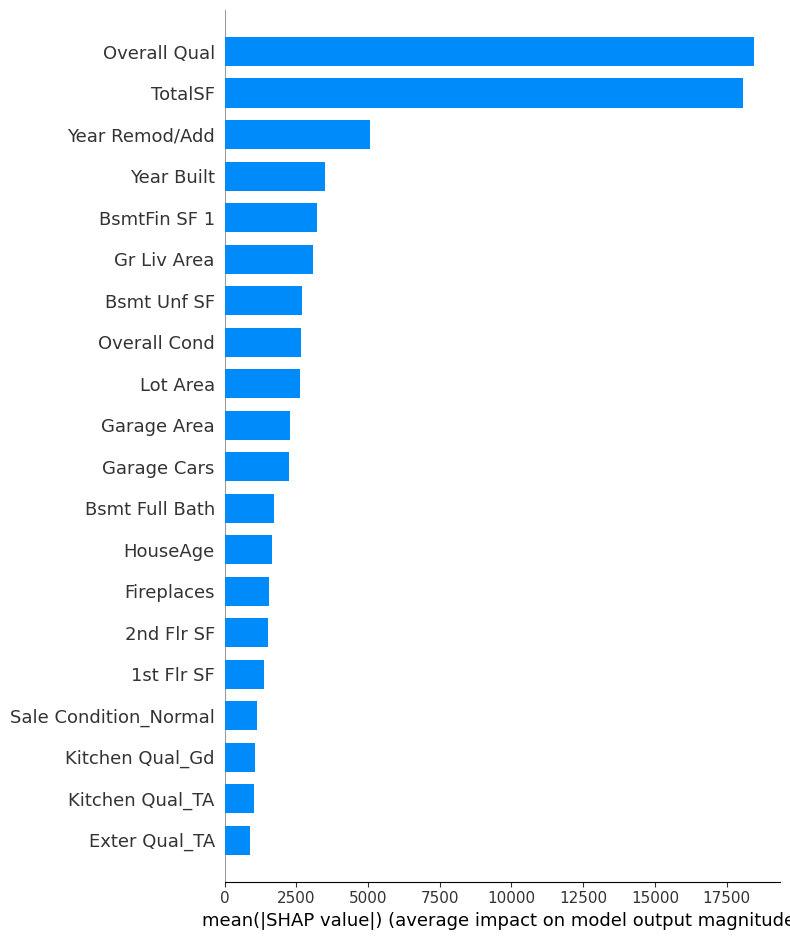

In [104]:
#Summary Plot (Global Importance)
shap.summary_plot(shap_values, X_test, plot_type="bar")

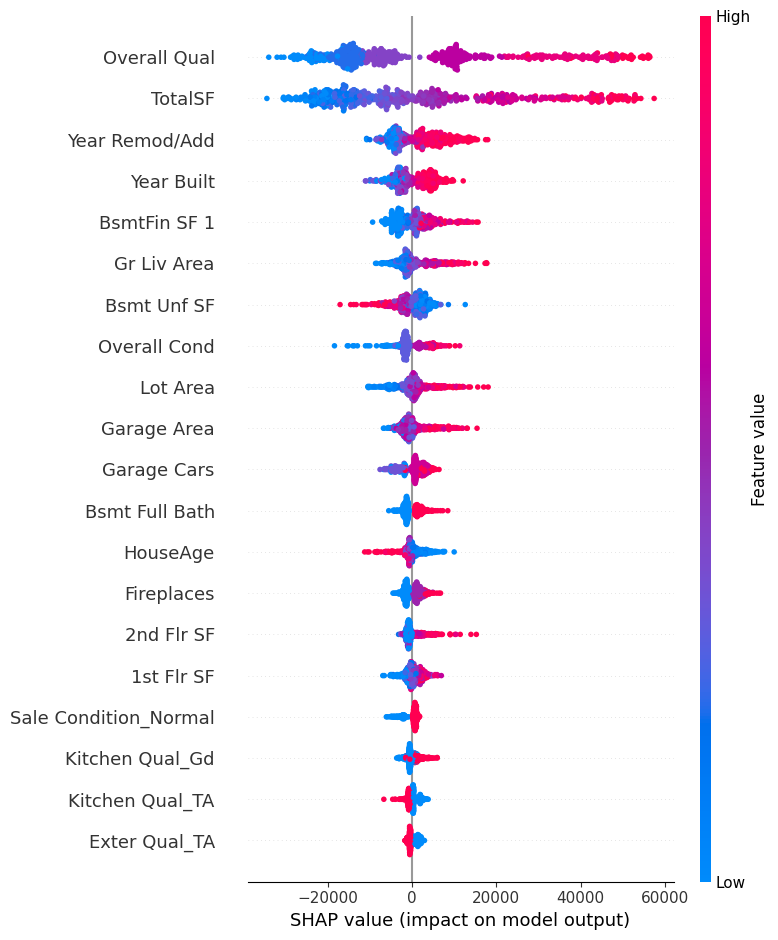

In [105]:
#Besswarm plot
shap.summary_plot(shap_values, X_test)

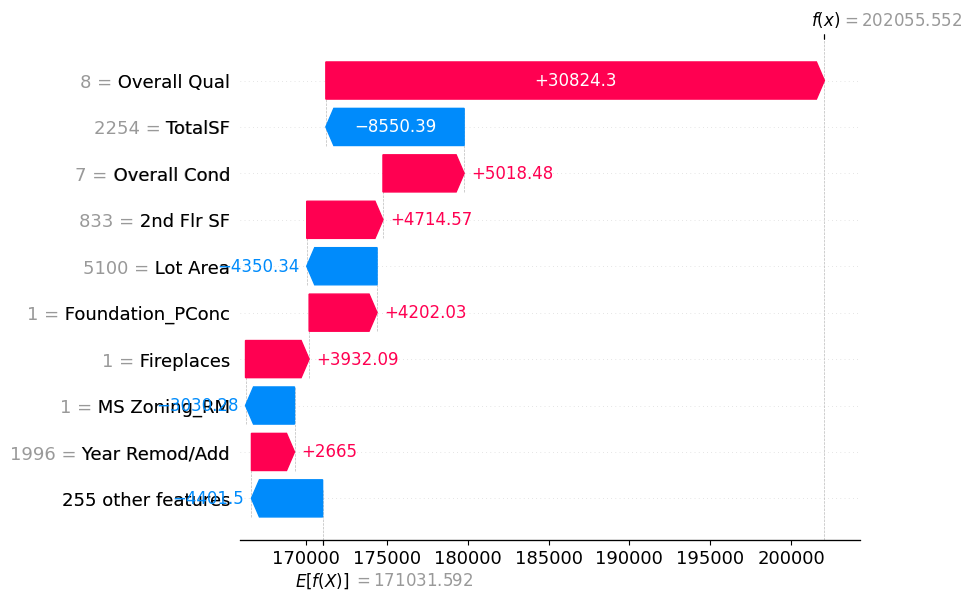

In [106]:
#Waterfall Plot (Single Prediction Explanation)
shap.plots.waterfall(shap_values[0])  # 0 = index of sample in X_test

In [107]:
#Force Plot (Single Sample, Interactive in Jupyter)
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values.values[0], X_test.iloc[0])

## Explain individual predictions (e.g., why a house is priced high)
- Positive SHAP Values:
Indicate that a feature's value contributes to a higher predicted price.
- Negative SHAP Values:
Indicate that a feature's value contributes to a lower predicted price.
- Magnitude of SHAP Values:
It represent the strength of the feature's influence of the price.
- SHAP Summary Plot: visualize the distribution of SHAP values for each feature, allowing you
to see the overall impact and direction of each feature's influence.
We conclude that these factors are expressed in the high house price by concluding the top 10 feature performances.
These features are TotalSF, Overall Qual, Gr Liv Area, Year Remod/Add, HouseAge, Overall Cond, Year Built, Garage Cars, Kitchen Qual, Lot Area.
These features are TotalSF, HouseAge, Year Built, MS Zoning, Lot Area shows that negative SHAP values and decrease the house price.
Finally Overall Qual, Overall Cond, Fireplaces, 2nd Flr SF these features express positive SHAP values and increase the house price.

# RMSE, MAE, R² on test set

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Print results
print(f"MAE (Mean Absolute Error): {mae:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

## Final Summary

## Best performing model and why?
#Best Performing Model:
Looking at the model performance comparison table and charts, the Voting Regressor typically emerage as one of the performers
often achieving the lowest MAE, RMSE & highest R2-Score. The Voting Regressor demonstrates a strong balance between accuracy and explanatory
power. It workesby aggregating the predictions of the base models, through majority Voting(hard voting) or average probabilities (soft voting).
Combing multiple models can often lead to better accuracy and generalization performance compared to using a single model.
- RMSE(Root Mean Squard Error):
The metric represents the Standard Deviation of the residuals (Predictions Errors). A lower RMSE indicates a better fit to the data.
- R2-Score:
This metric represents the proportion of the variance in the dependent variable that predictable from the independent variables.
An R2-Score close to 1 indicates a model that explains more of the variance.

## Key features influencing price:
According to SHAP top key feature which is influencing the price. These are shown below:
- TotalSF
- Overall Qual
- Gr Liv Area
- Year Remod/Add,
- HouseAge
- Overall Cond
- Year Built
- Garage Cars
- Kitchen Qual
- Lot Area.

# Final RMSE, MAE, R² on test set

- MAE (Mean Absolute Error): 13035.55
- RMSE (Root Mean Squared Error): 18315.11
- R² Score: 0.9371

# Visual explanation of predictions using SHAP

## Summary Plot (Global Importance)
- The summary plot shows the feature importance of each feature in the model. The results show that
“TotalSF,” “ Overall Qual,” and “Year Remod/Add”,“Gr Liv Area”, “Year Built” play major roles in
determining the results.

## Besswarm plot
A SHAP beeswarm plot will help to identify the most important features in a model SHAP plot can show you which features have the biggest impact on
the model's predictions. It express that the nature of these relationships when we use this plot.
We can notice that as the feature value “TotalSF” increase, the SHAP value also increase. Looking at the Beeswarm plot we can see that large SHAP values
for this feature are associated with smaller SHAP value.

## Waterfall Plot:
A waterfall plot shows how the prediction changes step by step, with each feature's contribution(Positive or negative) moving the prediction from the base value to the final prediction. The base value is the average prediction over all training samples. Each bar represents a feature’s contribution to pushing the predicted price higher (blue) or lower (red). The final predicted SalePrice is the sum of the base value and all SHAP contributions.

# Force Plot
We can see that we have the base value before and we can also see how each feature has contribution to the final prediction of 185,620.79.